In [146]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

pd.set_option('future.no_silent_downcasting', True)

df = pd.read_csv('processed_data.csv', index_col=0)
df.head()

,Age (>35),Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,Country,PrevSalary,Skills,Num_of_skills,Employed
0,0,0,Master,1,1,0,1,7,Sweden,51552,C++;Python;Git;PostgreSQL,4,0
1,0,0,Undergraduate,1,1,0,1,12,Spain,46482,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,12,1
2,0,0,Master,1,1,0,1,15,Germany,77290,C;C++;Java;Perl;Ruby;Git;Ruby on Rails,7,0
3,0,0,Undergraduate,1,1,0,1,9,Canada,46135,Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...,13,0
4,1,0,PhD,0,1,0,0,40,Singapore,160932,C++;Python,2,0


In [147]:
# Dropping string columns
df = df.drop(columns=['EdLevel','Country','Skills'])
df.head()

,Age (>35),Accessibility,Employment,Gender,MentalHealth,MainBranch,YearsCode,PrevSalary,Num_of_skills,Employed
0,0,0,1,1,0,1,7,51552,4,0
1,0,0,1,1,0,1,12,46482,12,1
2,0,0,1,1,0,1,15,77290,7,0
3,0,0,1,1,0,1,9,46135,13,0
4,1,0,0,1,0,0,40,160932,2,0


# Downsampling

In [148]:
df_female = df[df['Gender'] == 0]
df_male = df[df['Gender'] == 1]

n_female = len(df_female)
fixed_total = int(n_female / 0.70)

def get_downsampled_df(df_male, df_female, target_male_percent):    
    n_males_to_keep = int(fixed_total * target_male_percent)
    n_females_to_keep = fixed_total - n_males_to_keep
    
    # We sample BOTH to keep the total count identical
    df_m = df_male.sample(n=n_males_to_keep, random_state=42)
    df_f = df_female.sample(n=n_females_to_keep, random_state=42)
    
    return pd.concat([df_m, df_f]).sample(frac=1, random_state=42)

df_30_70 = get_downsampled_df(df_male, df_female, 0.30)
df_40_60 = get_downsampled_df(df_male, df_female, 0.40)
df_50_50 = get_downsampled_df(df_male, df_female, 0.50)
df_60_40 = get_downsampled_df(df_male, df_female, 0.60)
df_70_30 = get_downsampled_df(df_male, df_female, 0.70)

print(f"30/70 Set: {df_30_70['Gender'].value_counts()}")
print(f"40/60 Set: {df_40_60['Gender'].value_counts()}")
print(f"50/50 Set: {df_50_50['Gender'].value_counts()}")
print(f"60/40 Set: {df_60_40['Gender'].value_counts()}")
print(f"70/30 Set: {df_70_30['Gender'].value_counts()}")

30/70 Set: Gender
0    4878
1    2090
Name: count, dtype: int64
40/60 Set: Gender
0    4181
1    2787
Name: count, dtype: int64
50/50 Set: Gender
0    3484
1    3484
Name: count, dtype: int64
60/40 Set: Gender
1    4180
0    2788
Name: count, dtype: int64
70/30 Set: Gender
1    4877
0    2091
Name: count, dtype: int64


In [149]:
dfs = {"orig": df, "50_50": df_50_50, "60_40": df_60_40, "70_30": df_70_30, "40_60": df_40_60, "30_70": df_30_70}

X_y_pairs = {name: (d.drop(columns=['Employed']), d['Employed']) for name, d in dfs.items()}

## Splitting and Normalizing the Data

In [150]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# --- Original data block ---
X_orig, y_orig = X_y_pairs["orig"]
gender_orig = X_orig['Gender']

X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
    X_orig, y_orig, gender_orig, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 30/70 data block ---
X_30, y_30 = X_y_pairs["30_70"]
gender_30 = X_30['Gender']

X_train2, X_test2, y_train2, y_test2, gender_train2, gender_test2 = train_test_split(
    X_30, y_30, gender_30, test_size=0.2, random_state=42)

X_train_scaled2 = scaler.fit_transform(X_train2)
X_test_scaled2 = scaler.transform(X_test2)

# --- 40/60 data block ---
X_40, y_40 = X_y_pairs["40_60"]
gender_40 = X_40['Gender']

X_train3, X_test3, y_train3, y_test3, gender_train3, gender_test3 = train_test_split(
    X_40, y_40, gender_40, test_size=0.2, random_state=42)

X_train_scaled3 = scaler.fit_transform(X_train3)
X_test_scaled3 = scaler.transform(X_test3)

# --- 50/50 data block ---
X_50, y_50 = X_y_pairs["50_50"]
gender_50 = X_50['Gender']

X_train4, X_test4, y_train4, y_test4, gender_train4, gender_test4 = train_test_split(
    X_50, y_50, gender_50, test_size=0.2, random_state=42)

X_train_scaled4 = scaler.fit_transform(X_train4)
X_test_scaled4 = scaler.transform(X_test4)

# --- 60/40 data block ---
X_60, y_60 = X_y_pairs["60_40"]
gender_60 = X_60['Gender']

X_train5, X_test5, y_train5, y_test5, gender_train5, gender_test5 = train_test_split(
    X_60, y_60, gender_60, test_size=0.2, random_state=42)

X_train_scaled5 = scaler.fit_transform(X_train5)
X_test_scaled5 = scaler.transform(X_test5)

# --- 70/30 data block ---
X_70, y_70 = X_y_pairs["70_30"]
gender_70 = X_70['Gender']

X_train6, X_test6, y_train6, y_test6, gender_train6, gender_test6 = train_test_split(
    X_70, y_70, gender_70, test_size=0.2, random_state=42)

X_train_scaled6 = scaler.fit_transform(X_train6)
X_test_scaled6 = scaler.transform(X_test6)

## Evaluate Fairness for original data

In [151]:
def evaluate_fairness(y_true, y_pred, model_name, gender_test_data):
    # Build results dataframe
    # We are using y_test.index to ensure that we pull the correct Gender from the original dataset
    results = pd.DataFrame({
        "y_true": y_true.values, 
        "y_pred": y_pred,
        "Gender": gender_test_data.values
    })

    # 2) Initialize storage for this specific model
    gender_groups = [0, 1] # 0: Female, 1: Male
    genders_order = ["Female", "Male"]
    confusion_tables = {}
    current_sp = []
    current_tpr = []
    current_fpr = []
    rates = {}
    gender_acc_list = []

    # 3) Process each gender
    for g in gender_groups:
        subset = results[results["Gender"] == g]
        gender_label = "Female" if g == 0 else "Male"
        
        # Calculate Confusion Matrix
        cm = confusion_matrix(subset["y_true"], subset["y_pred"], labels=[1, 0])
        confusion_tables[gender_label] = pd.DataFrame(
            cm, 
            index=["Actual Employed", "Actual Not Employed"],
            columns=["Predicted Employed", "Predicted Not Employed"]
        )
        
        # Extract values
        tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
        
        # Calculate Metrics
        total = tp + tn + fp + fn
        tpr = tp / (tp + fn) if (tp + fn) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan

        gender_acc = (tp + tn) / total
        #print(f"Accuracy for {gender_label.lower()}: {round(gender_acc, 4)}")
        gender_acc_list.append(gender_acc)
        # Store for the global lists (sp_lr, etc.)
        current_sp.append((tp + fp) / total)
        current_tpr.append(tpr)
        current_fpr.append(fpr)

        rates[gender_label] = {
            "True Positive Rate": tpr,
            "False Positive Rate": fpr,
            "True Negative Rate": tn / (tn + fp) if (tn + fp) else np.nan,
            "False Negative Rate": fn / (fn + tp) if (fn + tp) else np.nan
        }
        '''
        print(f"\nConfusion Matrix for {model_name} (Gender = {gender_label})")
        display(confusion_tables[gender_label])
        '''

    # Display Rates Table
    '''
    df_rates = pd.DataFrame(rates).T
    print("\nRates:")
    display(df_rates.round(2))
    '''
    # Show model accuracy
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f_score = f1_score(y_true, y_pred)
    #print(f'Model Accuracy ({model_name}): {round(accuracy, 3)}')
    '''
    print(f'Model Precision score ({model_name}): {round(precision, 3)}')
    print(f'Model Recall score ({model_name}): {round(recall, 3)}')
    print(f'Model F1 score ({model_name}): {round(f_score, 3)}')
    #  Visualization
    df_rates = pd.DataFrame(rates).T
    ax = df_rates.plot(kind="bar", width=0.75)
    plt.title(f"Fairness Metrics: {model_name}")
    plt.ylabel("Rate")
    plt.ylim(0, 1)
    plt.show()
    '''
    
    # Return the metrics so you can use them in your fairness measurements
    return current_sp, current_tpr, current_fpr, gender_acc_list, accuracy

# Logistic Regression
lr_model = LogisticRegression(random_state=42).fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
sp_lr, TPR_lr, FPR_lr, gender_acc_lr, model_acc_lr = evaluate_fairness(y_test, y_pred_lr, "Logistic Regression", gender_test)

lr_model2 = LogisticRegression(random_state=42).fit(X_train_scaled2, y_train2)
y_pred_lr2 = lr_model2.predict(X_test_scaled2)
sp_lr2, TPR_lr2, FPR_lr2, gender_acc_lr2, model_acc_lr2 = evaluate_fairness(y_test2, y_pred_lr2, "Logistic Regression (30/70)", gender_test2)

lr_model3 = LogisticRegression(random_state=42).fit(X_train_scaled3, y_train3)
y_pred_lr3 = lr_model3.predict(X_test_scaled3)
sp_lr3, TPR_lr3, FPR_lr3, gender_acc_lr3, model_acc_lr3 = evaluate_fairness(y_test3, y_pred_lr3, "Logistic Regression (40/60)", gender_test3)

lr_model4 = LogisticRegression(random_state=42).fit(X_train_scaled4, y_train4)
y_pred_lr4 = lr_model4.predict(X_test_scaled4)
sp_lr4, TPR_lr4, FPR_lr4, gender_acc_lr4, model_acc_lr4 = evaluate_fairness(y_test4, y_pred_lr4, "Logistic Regression (50/50)", gender_test4)

lr_model5 = LogisticRegression(random_state=42).fit(X_train_scaled5, y_train5)
y_pred_lr5 = lr_model5.predict(X_test_scaled5)
sp_lr5, TPR_lr5, FPR_lr5, gender_acc_lr5, model_acc_lr5 = evaluate_fairness(y_test5, y_pred_lr5, "Logistic Regression (60/40)", gender_test5)

lr_model6 = LogisticRegression(random_state=42).fit(X_train_scaled6, y_train6)
y_pred_lr6 = lr_model6.predict(X_test_scaled6)
sp_lr6, TPR_lr6, FPR_lr6, gender_acc_lr6, model_acc_lr6 = evaluate_fairness(y_test6, y_pred_lr6, "Logistic Regression (70/30)", gender_test6)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
sp_rf, TPR_rf, FPR_rf, gender_acc_rf, model_acc_rf = evaluate_fairness(y_test, y_pred_rf, "Random Forest", gender_test)

rf_model2 = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_scaled2, y_train2)
y_pred_rf2 = rf_model2.predict(X_test_scaled2)
sp_rf2, TPR_rf2, FPR_rf2, gender_acc_rf2, model_acc_rf2 = evaluate_fairness(y_test2, y_pred_rf2, "Random Forest (30/70)", gender_test2)

rf_model3 = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_scaled3, y_train3)
y_pred_rf3 = rf_model3.predict(X_test_scaled3)
sp_rf3, TPR_rf3, FPR_rf3, gender_acc_rf3, model_acc_rf3 = evaluate_fairness(y_test3, y_pred_rf3, "Random Forest (40/60)", gender_test3)

rf_model4 = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_scaled4, y_train4)
y_pred_rf4 = rf_model4.predict(X_test_scaled4)
sp_rf4, TPR_rf4, FPR_rf4, gender_acc_rf4, model_acc_rf4 = evaluate_fairness(y_test4, y_pred_rf4, "Random Forest (50/50)", gender_test4)

rf_model5 = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_scaled5, y_train5)
y_pred_rf5 = rf_model5.predict(X_test_scaled5)
sp_rf5, TPR_rf5, FPR_rf5, gender_acc_rf5, model_acc_rf5 = evaluate_fairness(y_test5, y_pred_rf5, "Random Forest (60/40)", gender_test5)

rf_model6 = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_scaled6, y_train6)
y_pred_rf6 = rf_model6.predict(X_test_scaled6)
sp_rf6, TPR_rf6, FPR_rf6, gender_acc_rf6, model_acc_rf6 = evaluate_fairness(y_test6, y_pred_rf6, "Random Forest (70/30)", gender_test6)

'''
# Gradient Boosting
gbc = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42).fit(X_train_scaled, y_train)
y_pred_gbc = gbc.predict(X_test_scaled)
sp_gbc, TPR_gbc, FPR_gbc, gender_acc_gbc, model_acc_gbc= evaluate_fairness(y_test, y_pred_gbc, "Gradient Boosting")
'''

#XGBoost
xgb = XGBClassifier(n_estimators=300, random_state=42).fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
sp_xgb, TPR_xgb, FPR_xgb, gender_acc_xgb, model_acc_xgb = evaluate_fairness(y_test, y_pred_xgb, "XGBoost", gender_test)

xgb2 = XGBClassifier(n_estimators=300, random_state=42).fit(X_train_scaled2, y_train2)
y_pred_xgb2 = xgb2.predict(X_test_scaled2)
sp_xgb2, TPR_xgb2, FPR_xgb2, gender_acc_xgb2, model_acc_xgb2 = evaluate_fairness(y_test2, y_pred_xgb2, "XGBoost (30/70)", gender_test2)

xgb3 = XGBClassifier(n_estimators=300, random_state=42).fit(X_train_scaled3, y_train3)
y_pred_xgb3 = xgb3.predict(X_test_scaled3)
sp_xgb3, TPR_xgb3, FPR_xgb3, gender_acc_xgb3, model_acc_xgb3 = evaluate_fairness(y_test3, y_pred_xgb3, "XGBoost (40/60)", gender_test3)

xgb4 = XGBClassifier(n_estimators=300, random_state=42).fit(X_train_scaled4, y_train4)
y_pred_xgb4 = xgb4.predict(X_test_scaled4)
sp_xgb4, TPR_xgb4, FPR_xgb4, gender_acc_xgb4, model_acc_xgb4 = evaluate_fairness(y_test4, y_pred_xgb4, "XGBoost (50/50)", gender_test4)

xgb5 = XGBClassifier(n_estimators=300, random_state=42).fit(X_train_scaled5, y_train5)
y_pred_xgb5 = xgb5.predict(X_test_scaled5)
sp_xgb5, TPR_xgb5, FPR_xgb5, gender_acc_xgb5, model_acc_xgb5 = evaluate_fairness(y_test5, y_pred_xgb5, "XGBoost (60/40)", gender_test5)

xgb6 = XGBClassifier(n_estimators=300, random_state=42).fit(X_train_scaled6, y_train6)
y_pred_xgb6 = xgb6.predict(X_test_scaled6)
sp_xgb6, TPR_xgb6, FPR_xgb6, gender_acc_xgb6, model_acc_xgb6 = evaluate_fairness(y_test6, y_pred_xgb6, "XGBoost (70/30)", gender_test6)

#SVM
svm = LinearSVC(random_state=42, dual=False).fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
sp_svm, TPR_svm, FPR_svm, gender_acc_svm, model_acc_svm = evaluate_fairness(y_test, y_pred_svm, "SVM", gender_test)

svm2 = LinearSVC(random_state=42, dual=False).fit(X_train_scaled2, y_train2)
y_pred_svm2 = svm2.predict(X_test_scaled2)
sp_svm2, TPR_svm2, FPR_svm2, gender_acc_svm2, model_acc_svm2 = evaluate_fairness(y_test2, y_pred_svm2, "SVM (30/70)", gender_test2)

svm3 = LinearSVC(random_state=42, dual=False).fit(X_train_scaled3, y_train3)
y_pred_svm3 = svm3.predict(X_test_scaled3)
sp_svm3, TPR_svm3, FPR_svm3, gender_acc_svm3, model_acc_svm3 = evaluate_fairness(y_test3, y_pred_svm3, "SVM (40/60)", gender_test3)

svm4 = LinearSVC(random_state=42, dual=False).fit(X_train_scaled4, y_train4)
y_pred_svm4 = svm4.predict(X_test_scaled4)
sp_svm4, TPR_svm4, FPR_svm4, gender_acc_svm4, model_acc_svm4 = evaluate_fairness(y_test4, y_pred_svm4, "SVM (50/50)", gender_test4)

svm5 = LinearSVC(random_state=42, dual=False).fit(X_train_scaled5, y_train5)
y_pred_svm5 = svm5.predict(X_test_scaled5)
sp_svm5, TPR_svm5, FPR_svm5, gender_acc_svm5, model_acc_svm5 = evaluate_fairness(y_test5, y_pred_svm5, "SVM (60/40)", gender_test5)

svm6 = LinearSVC(random_state=42, dual=False).fit(X_train_scaled6, y_train6)
y_pred_svm6 = svm6.predict(X_test_scaled6)
sp_svm6, TPR_svm6, FPR_svm6, gender_acc_svm6, model_acc_svm6 = evaluate_fairness(y_test6, y_pred_svm6, "SVM (70/30)", gender_test6)

#KNN
knn = KNeighborsClassifier(n_neighbors=17).fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
sp_knn, TPR_knn, FPR_knn, gender_acc_knn, model_acc_knn = evaluate_fairness(y_test, y_pred_knn, "KNN", gender_test)

knn2 = KNeighborsClassifier(n_neighbors=17).fit(X_train_scaled2, y_train2)
y_pred_knn2 = knn2.predict(X_test_scaled2)
sp_knn2, TPR_knn2, FPR_knn2, gender_acc_knn2, model_acc_knn2 = evaluate_fairness(y_test2, y_pred_knn2, "KNN (30/70)", gender_test2)

knn3 = KNeighborsClassifier(n_neighbors=17).fit(X_train_scaled3, y_train3)
y_pred_knn3 = knn3.predict(X_test_scaled3)
sp_knn3, TPR_knn3, FPR_knn3, gender_acc_knn3, model_acc_knn3 = evaluate_fairness(y_test3, y_pred_knn3, "KNN (40/60)", gender_test3)

knn4 = KNeighborsClassifier(n_neighbors=17).fit(X_train_scaled4, y_train4)
y_pred_knn4 = knn4.predict(X_test_scaled4)
sp_knn4, TPR_knn4, FPR_knn4, gender_acc_knn4, model_acc_knn4 = evaluate_fairness(y_test4, y_pred_knn4, "KNN (50/50)", gender_test4)

knn5 = KNeighborsClassifier(n_neighbors=17).fit(X_train_scaled5, y_train5)
y_pred_knn5 = knn5.predict(X_test_scaled5)
sp_knn5, TPR_knn5, FPR_knn5, gender_acc_knn5, model_acc_knn5 = evaluate_fairness(y_test5, y_pred_knn5, "KNN (60/40)", gender_test5)

knn6 = KNeighborsClassifier(n_neighbors=17).fit(X_train_scaled6, y_train6)
y_pred_knn6 = knn6.predict(X_test_scaled6)
sp_knn6, TPR_knn6, FPR_knn6, gender_acc_knn6, model_acc_knn6 = evaluate_fairness(y_test6, y_pred_knn6, "KNN (70/30)", gender_test6)

#Naive bayes
nb = GaussianNB().fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
sp_nb, TPR_nb, FPR_nb, gender_acc_nb, model_acc_nb = evaluate_fairness(y_test, y_pred_nb, "Naive Bayes", gender_test)

nb2 = GaussianNB().fit(X_train2, y_train2)
y_pred_nb2 = nb2.predict(X_test2)
sp_nb2, TPR_nb2, FPR_nb2, gender_acc_nb2, model_acc_nb2 = evaluate_fairness(y_test2, y_pred_nb2, "Naive Bayes (30/70)", gender_test2)

nb3 = GaussianNB().fit(X_train3, y_train3)
y_pred_nb3 = nb3.predict(X_test3)
sp_nb3, TPR_nb3, FPR_nb3, gender_acc_nb3, model_acc_nb3 = evaluate_fairness(y_test3, y_pred_nb3, "Naive Bayes (40/60)", gender_test3)

nb4 = GaussianNB().fit(X_train4, y_train4)
y_pred_nb4 = nb4.predict(X_test4)
sp_nb4, TPR_nb4, FPR_nb4, gender_acc_nb4, model_acc_nb4 = evaluate_fairness(y_test4, y_pred_nb4, "Naive Bayes (50/50)", gender_test4)

nb5 = GaussianNB().fit(X_train5, y_train5)
y_pred_nb5 = nb5.predict(X_test5)
sp_nb5, TPR_nb5, FPR_nb5, gender_acc_nb5, model_acc_nb5 = evaluate_fairness(y_test5, y_pred_nb5, "Naive Bayes (60/40)", gender_test5)

nb6 = GaussianNB().fit(X_train6, y_train6)
y_pred_nb6 = nb6.predict(X_test6)
sp_nb6, TPR_nb6, FPR_nb6, gender_acc_nb6, model_acc_nb6 = evaluate_fairness(y_test6, y_pred_nb6, "Naive Bayes (70/30)", gender_test6)

### Overall model's accuracy metrics (original result excluded)

In [152]:
# Logistic Regression
print(f"Logistic Regression Mean Metrics:\n- Overall Accuracy: {round(np.mean([model_acc_lr2, model_acc_lr3, model_acc_lr4, model_acc_lr5, model_acc_lr6]), 4)}\n- Female Accuracy:  {round(np.mean([acc[0] for acc in [gender_acc_lr2, gender_acc_lr3, gender_acc_lr4, gender_acc_lr5, gender_acc_lr6]]), 4)}\n- Male Accuracy:    {round(np.mean([acc[1] for acc in [gender_acc_lr2, gender_acc_lr3, gender_acc_lr4, gender_acc_lr5, gender_acc_lr6]]), 4)}\n")

# Random Forest
print(f"Random Forest Mean Metrics:\n- Overall Accuracy: {round(np.mean([model_acc_rf2, model_acc_rf3, model_acc_rf4, model_acc_rf5, model_acc_rf6]), 4)}\n- Female Accuracy:  {round(np.mean([acc[0] for acc in [gender_acc_rf2, gender_acc_rf3, gender_acc_rf4, gender_acc_rf5, gender_acc_rf6]]), 4)}\n- Male Accuracy:    {round(np.mean([acc[1] for acc in [gender_acc_rf2, gender_acc_rf3, gender_acc_rf4, gender_acc_rf5, gender_acc_rf6]]), 4)}\n")

# XGBoost
print(f"XGBoost Mean Metrics:\n- Overall Accuracy: {round(np.mean([model_acc_xgb2, model_acc_xgb3, model_acc_xgb4, model_acc_xgb5, model_acc_xgb6]), 4)}\n- Female Accuracy:  {round(np.mean([acc[0] for acc in [gender_acc_xgb2, gender_acc_xgb3, gender_acc_xgb4, gender_acc_xgb5, gender_acc_xgb6]]), 4)}\n- Male Accuracy:    {round(np.mean([acc[1] for acc in [gender_acc_xgb2, gender_acc_xgb3, gender_acc_xgb4, gender_acc_xgb5, gender_acc_xgb6]]), 4)}\n")

# SVM
print(f"SVM Mean Metrics:\n- Overall Accuracy: {round(np.mean([model_acc_svm2, model_acc_svm3, model_acc_svm4, model_acc_svm5, model_acc_svm6]), 4)}\n- Female Accuracy:  {round(np.mean([acc[0] for acc in [gender_acc_svm2, gender_acc_svm3, gender_acc_svm4, gender_acc_svm5, gender_acc_svm6]]), 4)}\n- Male Accuracy:    {round(np.mean([acc[1] for acc in [gender_acc_svm2, gender_acc_svm3, gender_acc_svm4, gender_acc_svm5, gender_acc_svm6]]), 4)}\n")

# KNN
print(f"KNN Mean Metrics:\n- Overall Accuracy: {round(np.mean([model_acc_knn2, model_acc_knn3, model_acc_knn4, model_acc_knn5, model_acc_knn6]), 4)}\n- Female Accuracy:  {round(np.mean([acc[0] for acc in [gender_acc_knn2, gender_acc_knn3, gender_acc_knn4, gender_acc_knn5, gender_acc_knn6]]), 4)}\n- Male Accuracy:    {round(np.mean([acc[1] for acc in [gender_acc_knn2, gender_acc_knn3, gender_acc_knn4, gender_acc_knn5, gender_acc_knn6]]), 4)}\n")

# Naive Bayes
print(f"Naive Bayes Mean Metrics:\n- Overall Accuracy: {round(np.mean([model_acc_nb2, model_acc_nb3, model_acc_nb4, model_acc_nb5, model_acc_nb6]), 4)}\n- Female Accuracy:  {round(np.mean([acc[0] for acc in [gender_acc_nb2, gender_acc_nb3, gender_acc_nb4, gender_acc_nb5, gender_acc_nb6]]), 4)}\n- Male Accuracy:    {round(np.mean([acc[1] for acc in [gender_acc_nb2, gender_acc_nb3, gender_acc_nb4, gender_acc_nb5, gender_acc_nb6]]), 4)}\n")

Logistic Regression Mean Metrics:
- Overall Accuracy: 0.7984
- Female Accuracy:  0.7997
- Male Accuracy:    0.7983

Random Forest Mean Metrics:
- Overall Accuracy: 0.7643
- Female Accuracy:  0.7725
- Male Accuracy:    0.756

XGBoost Mean Metrics:
- Overall Accuracy: 0.7496
- Female Accuracy:  0.7604
- Male Accuracy:    0.7393

SVM Mean Metrics:
- Overall Accuracy: 0.7967
- Female Accuracy:  0.7981
- Male Accuracy:    0.7974

KNN Mean Metrics:
- Overall Accuracy: 0.7743
- Female Accuracy:  0.7841
- Male Accuracy:    0.7633

Naive Bayes Mean Metrics:
- Overall Accuracy: 0.7697
- Female Accuracy:  0.7784
- Male Accuracy:    0.7622



# Statistical Parity Difference
### $$SPD = Pr(\hat{Y} = 1 \mid D = \text{unprivileged}) - Pr(\hat{Y} = 1 \mid D = \text{privileged})$$

### NOTE: Original testing result excluded during calculation of mean

In [153]:
SPD_orig_lr, SPD_orig_lr2, SPD_orig_lr3, SPD_orig_lr4, SPD_orig_lr5, SPD_orig_lr6 = [round(s[0] - s[1], 4) for s in [sp_lr, sp_lr2, sp_lr3, sp_lr4, sp_lr5, sp_lr6]]
SPD_orig_rf, SPD_orig_rf2, SPD_orig_rf3, SPD_orig_rf4, SPD_orig_rf5, SPD_orig_rf6 = [round(s[0] - s[1], 4) for s in [sp_rf, sp_rf2, sp_rf3, sp_rf4, sp_rf5, sp_rf6]]
SPD_orig_xgb, SPD_orig_xgb2, SPD_orig_xgb3, SPD_orig_xgb4, SPD_orig_xgb5, SPD_orig_xgb6 = [round(s[0] - s[1], 4) for s in [sp_xgb, sp_xgb2, sp_xgb3, sp_xgb4, sp_xgb5, sp_xgb6]]
SPD_orig_svm, SPD_orig_svm2, SPD_orig_svm3, SPD_orig_svm4, SPD_orig_svm5, SPD_orig_svm6 = [round(s[0] - s[1], 4) for s in [sp_svm, sp_svm2, sp_svm3, sp_svm4, sp_svm5, sp_svm6]]
SPD_orig_knn, SPD_orig_knn2, SPD_orig_knn3, SPD_orig_knn4, SPD_orig_knn5, SPD_orig_knn6 = [round(s[0] - s[1], 4) for s in [sp_knn, sp_knn2, sp_knn3, sp_knn4, sp_knn5, sp_knn6]]
SPD_orig_nb, SPD_orig_nb2, SPD_orig_nb3, SPD_orig_nb4, SPD_orig_nb5, SPD_orig_nb6 = [round(s[0] - s[1], 4) for s in [sp_nb, sp_nb2, sp_nb3, sp_nb4, sp_nb5, sp_nb6]]
down_avg_spd_lr = round(np.mean([SPD_orig_lr2, SPD_orig_lr3, SPD_orig_lr4, SPD_orig_lr5, SPD_orig_lr6]), 4)  # Original testing result excluded 
down_avg_spd_rf = round(np.mean([SPD_orig_rf2, SPD_orig_rf3, SPD_orig_rf4, SPD_orig_rf5, SPD_orig_rf6]), 4)
down_avg_spd_xgb = round(np.mean([SPD_orig_xgb2, SPD_orig_xgb3, SPD_orig_xgb4, SPD_orig_xgb5, SPD_orig_xgb6]), 4)
down_avg_spd_svm = round(np.mean([SPD_orig_svm2, SPD_orig_svm3, SPD_orig_svm4, SPD_orig_svm5, SPD_orig_svm6]), 4)
down_avg_spd_knn = round(np.mean([SPD_orig_knn2, SPD_orig_knn3, SPD_orig_knn4, SPD_orig_knn5, SPD_orig_knn6]), 4)
down_avg_spd_nb = round(np.mean([SPD_orig_nb2, SPD_orig_nb3, SPD_orig_nb4, SPD_orig_nb5, SPD_orig_nb6]), 4)

'''
print(f'Logistic Regression -> {SPD_orig_lr} \nLogistic Regression (30/70) -> {SPD_orig_lr2} \nLogistic Regression (40/60) -> {SPD_orig_lr3}\nLogistic Regression (50/50) -> {SPD_orig_lr4}\nLogistic Regression (60/40) -> {SPD_orig_lr5}\nLogistic Regression (70/30) -> {SPD_orig_lr6}\nLogistic Regression (mean) -> {down_avg_spd_lr}')
print(f'Random Forest -> {SPD_orig_rf} \nRandom Forest (30/70) -> {SPD_orig_rf2} \nRandom Forest (40/60) -> {SPD_orig_rf3} \nRandom Forest (50/50) -> {SPD_orig_rf4}\nRandom Forest (60/40) -> {SPD_orig_rf5}\nRandom Forest (70/30) -> {SPD_orig_rf6}\nRandom Forest (mean) -> {down_avg_spd_rf}')
print(f'XGBoost -> {SPD_orig_xgb} \nXGBoost (30/70) -> {SPD_orig_xgb2} \nXGBoost (40/60) -> {SPD_orig_xgb3}\nXGBoost (50/50) -> {SPD_orig_xgb4}\nXGBoost (60/40) -> {SPD_orig_xgb5}\nXGBoost (70/30) -> {SPD_orig_xgb6}\nXGBoost (mean) -> {down_avg_spd_xgb}')
print(f'SVM -> {SPD_orig_svm} \nSVM (30/70) -> {SPD_orig_svm2} \nSVM (40/60) -> {SPD_orig_svm3}\nSVM (50/50) -> {SPD_orig_svm4}\nSVM (60/40) -> {SPD_orig_svm5}\nSVM (70/30) -> {SPD_orig_svm6}\nSVM (mean) -> {down_avg_spd_svm}')
print(f'KNN -> {SPD_orig_knn} \nKNN (30/70) -> {SPD_orig_knn2} \nKNN (40/60) -> {SPD_orig_knn3}\nKNN (50/50) -> {SPD_orig_knn4}\nKNN (60/40) -> {SPD_orig_knn5}\nKNN (70/30) -> {SPD_orig_knn6}\nKNN (mean) -> {down_avg_spd_knn}')
print(f'Naive Bayes -> {SPD_orig_nb} \nNaive Bayes (30/70) -> {SPD_orig_nb2} \nNaive Bayes (40/60) -> {SPD_orig_nb3}\nNaive Bayes (50/50) -> {SPD_orig_nb4}\nNaive Bayes (60/40) -> {SPD_orig_nb5}\nNaive Bayes (70/30) -> {SPD_orig_nb6}\nNaive Bayes (mean) -> {down_avg_spd_nb}')
'''

"\nprint(f'Logistic Regression -> {SPD_orig_lr} \nLogistic Regression (30/70) -> {SPD_orig_lr2} \nLogistic Regression (40/60) -> {SPD_orig_lr3}\nLogistic Regression (50/50) -> {SPD_orig_lr4}\nLogistic Regression (60/40) -> {SPD_orig_lr5}\nLogistic Regression (70/30) -> {SPD_orig_lr6}\nLogistic Regression (mean) -> {down_avg_spd_lr}')\nprint(f'Random Forest -> {SPD_orig_rf} \nRandom Forest (30/70) -> {SPD_orig_rf2} \nRandom Forest (40/60) -> {SPD_orig_rf3} \nRandom Forest (50/50) -> {SPD_orig_rf4}\nRandom Forest (60/40) -> {SPD_orig_rf5}\nRandom Forest (70/30) -> {SPD_orig_rf6}\nRandom Forest (mean) -> {down_avg_spd_rf}')\nprint(f'XGBoost -> {SPD_orig_xgb} \nXGBoost (30/70) -> {SPD_orig_xgb2} \nXGBoost (40/60) -> {SPD_orig_xgb3}\nXGBoost (50/50) -> {SPD_orig_xgb4}\nXGBoost (60/40) -> {SPD_orig_xgb5}\nXGBoost (70/30) -> {SPD_orig_xgb6}\nXGBoost (mean) -> {down_avg_spd_xgb}')\nprint(f'SVM -> {SPD_orig_svm} \nSVM (30/70) -> {SPD_orig_svm2} \nSVM (40/60) -> {SPD_orig_svm3}\nSVM (50/50) -> {

# Disparate Impact
### $$DI = \frac{Pr(\hat{Y} = 1 \mid D = \text{unprivileged})}{Pr(\hat{Y} = 1 \mid D = \text{privileged})}$$ $$DI = \frac{\text{Selection Rate for Females}}{\text{Selection Rate for Males}}$$

In [154]:
DI_orig_lr, DI_orig_lr2, DI_orig_lr3, DI_orig_lr4, DI_orig_lr5, DI_orig_lr6 = [round(s[0] / s[1], 4) for s in [sp_lr, sp_lr2, sp_lr3, sp_lr4, sp_lr5, sp_lr6]]
DI_orig_rf, DI_orig_rf2, DI_orig_rf3, DI_orig_rf4, DI_orig_rf5, DI_orig_rf6 = [round(s[0] / s[1], 4) for s in [sp_rf, sp_rf2, sp_rf3, sp_rf4, sp_rf5, sp_rf6]]
DI_orig_xgb, DI_orig_xgb2, DI_orig_xgb3, DI_orig_xgb4, DI_orig_xgb5, DI_orig_xgb6 = [round(s[0] / s[1], 4) for s in [sp_xgb, sp_xgb2, sp_xgb3, sp_xgb4, sp_xgb5, sp_xgb6]]
DI_orig_svm, DI_orig_svm2, DI_orig_svm3, DI_orig_svm4, DI_orig_svm5, DI_orig_svm6 = [round(s[0] / s[1], 4) for s in [sp_svm, sp_svm2, sp_svm3, sp_svm4, sp_svm5, sp_svm6]]
DI_orig_knn, DI_orig_knn2, DI_orig_knn3, DI_orig_knn4, DI_orig_knn5, DI_orig_knn6 = [round(s[0] / s[1], 4) for s in [sp_knn, sp_knn2, sp_knn3, sp_knn4, sp_knn5, sp_knn6]]
DI_orig_nb, DI_orig_nb2, DI_orig_nb3, DI_orig_nb4, DI_orig_nb5, DI_orig_nb6 = [round(s[0] / s[1], 4) for s in [sp_nb, sp_nb2, sp_nb3, sp_nb4, sp_nb5, sp_nb6]]
down_avg_DI_lr = round(np.mean([DI_orig_lr2, DI_orig_lr3, DI_orig_lr4, DI_orig_lr5, DI_orig_lr6]), 4)  # Original testing result excluded 
down_avg_DI_rf = round(np.mean([DI_orig_rf2, DI_orig_rf3, DI_orig_rf4, DI_orig_rf5, DI_orig_rf6]), 4)
down_avg_DI_xgb = round(np.mean([DI_orig_xgb2, DI_orig_xgb3, DI_orig_xgb4, DI_orig_xgb5, DI_orig_xgb6]), 4)
down_avg_DI_svm = round(np.mean([DI_orig_svm2, DI_orig_svm3, DI_orig_svm4, DI_orig_svm5, DI_orig_svm6]), 4)
down_avg_DI_knn = round(np.mean([DI_orig_knn2, DI_orig_knn3, DI_orig_knn4, DI_orig_knn5, DI_orig_knn6]), 4)
down_avg_DI_nb = round(np.mean([DI_orig_nb2, DI_orig_nb3, DI_orig_nb4, DI_orig_nb5, DI_orig_nb6]), 4)

'''
print(f'Logistic Regression -> {DI_orig_lr} \nLogistic Regression (30/70) -> {DI_orig_lr2} \nLogistic Regression (40/60) -> {DI_orig_lr3}\nLogistic Regression (50/50) -> {DI_orig_lr4}\nLogistic Regression (60/40) -> {DI_orig_lr5}\nLogistic Regression (70/30) -> {DI_orig_lr6}\nLogistic Regression (mean) -> {down_avg_DI_lr}')
print(f'Random Forest -> {DI_orig_rf} \nRandom Forest (30/70) -> {DI_orig_rf2} \nRandom Forest (40/60) -> {DI_orig_rf3} \nRandom Forest (50/50) -> {DI_orig_rf4}\nRandom Forest (60/40) -> {DI_orig_rf5}\nRandom Forest (70/30) -> {DI_orig_rf6}\nRandom Forest (mean) -> {down_avg_DI_rf}')
print(f'XGBoost -> {DI_orig_xgb} \nXGBoost (30/70) -> {DI_orig_xgb2} \nXGBoost (40/60) -> {DI_orig_xgb3}\nXGBoost (50/50) -> {DI_orig_xgb4}\nXGBoost (60/40) -> {DI_orig_xgb5}\nXGBoost (70/30) -> {DI_orig_xgb6}\nXGBoost (mean) -> {down_avg_DI_xgb}')
print(f'SVM -> {DI_orig_svm} \nSVM (30/70) -> {DI_orig_svm2} \nSVM (40/60) -> {DI_orig_svm3}\nSVM (50/50) -> {DI_orig_svm4}\nSVM (60/40) -> {DI_orig_svm5}\nSVM (70/30) -> {DI_orig_svm6}\nSVM (mean) -> {down_avg_DI_svm}')
print(f'KNN -> {DI_orig_knn} \nKNN (30/70) -> {DI_orig_knn2} \nKNN (40/60) -> {DI_orig_knn3}\nKNN (50/50) -> {DI_orig_knn4}\nKNN (60/40) -> {DI_orig_knn5}\nKNN (70/30) -> {DI_orig_knn6}\nKNN (mean) -> {down_avg_DI_knn}')
print(f'Naive Bayes -> {DI_orig_nb} \nNaive Bayes (30/70) -> {DI_orig_nb2} \nNaive Bayes (40/60) -> {DI_orig_nb3}\nNaive Bayes (50/50) -> {DI_orig_nb4}\nNaive Bayes (60/40) -> {DI_orig_nb5}\nNaive Bayes (70/30) -> {DI_orig_nb6}\nNaive Bayes (mean) -> {down_avg_DI_nb}')
'''

"\nprint(f'Logistic Regression -> {DI_orig_lr} \nLogistic Regression (30/70) -> {DI_orig_lr2} \nLogistic Regression (40/60) -> {DI_orig_lr3}\nLogistic Regression (50/50) -> {DI_orig_lr4}\nLogistic Regression (60/40) -> {DI_orig_lr5}\nLogistic Regression (70/30) -> {DI_orig_lr6}\nLogistic Regression (mean) -> {down_avg_DI_lr}')\nprint(f'Random Forest -> {DI_orig_rf} \nRandom Forest (30/70) -> {DI_orig_rf2} \nRandom Forest (40/60) -> {DI_orig_rf3} \nRandom Forest (50/50) -> {DI_orig_rf4}\nRandom Forest (60/40) -> {DI_orig_rf5}\nRandom Forest (70/30) -> {DI_orig_rf6}\nRandom Forest (mean) -> {down_avg_DI_rf}')\nprint(f'XGBoost -> {DI_orig_xgb} \nXGBoost (30/70) -> {DI_orig_xgb2} \nXGBoost (40/60) -> {DI_orig_xgb3}\nXGBoost (50/50) -> {DI_orig_xgb4}\nXGBoost (60/40) -> {DI_orig_xgb5}\nXGBoost (70/30) -> {DI_orig_xgb6}\nXGBoost (mean) -> {down_avg_DI_xgb}')\nprint(f'SVM -> {DI_orig_svm} \nSVM (30/70) -> {DI_orig_svm2} \nSVM (40/60) -> {DI_orig_svm3}\nSVM (50/50) -> {DI_orig_svm4}\nSVM (60/4

# Equal Opportunity
### $$\text{Equal Opportunity} = (TPR_{\text{Female}} - TPR_{\text{Male}})$$

In [155]:
EOD_orig_lr, EOD_orig_lr2, EOD_orig_lr3, EOD_orig_lr4, EOD_orig_lr5, EOD_orig_lr6 = [round(s[0] - s[1], 4) for s in [TPR_lr, TPR_lr2, TPR_lr3, TPR_lr4, TPR_lr5, TPR_lr6]]
EOD_orig_rf, EOD_orig_rf2, EOD_orig_rf3, EOD_orig_rf4, EOD_orig_rf5, EOD_orig_rf6 = [round(s[0] - s[1], 4) for s in [TPR_rf, TPR_rf2, TPR_rf3, TPR_rf4, TPR_rf5, TPR_rf6]]
EOD_orig_xgb, EOD_orig_xgb2, EOD_orig_xgb3, EOD_orig_xgb4, EOD_orig_xgb5, EOD_orig_xgb6 = [round(s[0] - s[1], 4) for s in [TPR_xgb, TPR_xgb2, TPR_xgb3, TPR_xgb4, TPR_xgb5, TPR_xgb6]]
EOD_orig_svm, EOD_orig_svm2, EOD_orig_svm3, EOD_orig_svm4, EOD_orig_svm5, EOD_orig_svm6 = [round(s[0] - s[1], 4) for s in [TPR_svm, TPR_svm2, TPR_svm3, TPR_svm4, TPR_svm5, TPR_svm6]]
EOD_orig_knn, EOD_orig_knn2, EOD_orig_knn3, EOD_orig_knn4, EOD_orig_knn5, EOD_orig_knn6 = [round(s[0] - s[1], 4) for s in [TPR_knn, TPR_knn2, TPR_knn3, TPR_knn4, TPR_knn5, TPR_knn6]]
EOD_orig_nb, EOD_orig_nb2, EOD_orig_nb3, EOD_orig_nb4, EOD_orig_nb5, EOD_orig_nb6 = [round(s[0] - s[1], 4) for s in [TPR_nb, TPR_nb2, TPR_nb3, TPR_nb4, TPR_nb5, TPR_nb6]]
down_avg_EOD_lr = round(np.mean([EOD_orig_lr2, EOD_orig_lr3, EOD_orig_lr4, EOD_orig_lr5, EOD_orig_lr6]), 4)  # Original testing result excluded 
down_avg_EOD_rf = round(np.mean([EOD_orig_rf2, EOD_orig_rf3, EOD_orig_rf4, EOD_orig_rf5, EOD_orig_rf6]), 4)
down_avg_EOD_xgb = round(np.mean([EOD_orig_xgb2, EOD_orig_xgb3, EOD_orig_xgb4, EOD_orig_xgb5, EOD_orig_xgb6]), 4)
down_avg_EOD_svm = round(np.mean([EOD_orig_svm2, EOD_orig_svm3, EOD_orig_svm4, EOD_orig_svm5, EOD_orig_svm6]), 4)
down_avg_EOD_knn = round(np.mean([EOD_orig_knn2, EOD_orig_knn3, EOD_orig_knn4, EOD_orig_knn5, EOD_orig_knn6]), 4)
down_avg_EOD_nb = round(np.mean([EOD_orig_nb2, EOD_orig_nb3, EOD_orig_nb4, EOD_orig_nb5, EOD_orig_nb6]), 4)

'''
print(f'Logistic Regression -> {EOD_orig_lr} \nLogistic Regression (30/70) -> {EOD_orig_lr2} \nLogistic Regression (40/60) -> {EOD_orig_lr3}\nLogistic Regression (50/50) -> {EOD_orig_lr4}\nLogistic Regression (60/40) -> {EOD_orig_lr5}\nLogistic Regression (70/30) -> {EOD_orig_lr6}\nLogistic Regression (mean) -> {down_avg_EOD_lr}')
print(f'Random Forest -> {EOD_orig_rf} \nRandom Forest (30/70) -> {EOD_orig_rf2} \nRandom Forest (40/60) -> {EOD_orig_rf3} \nRandom Forest (50/50) -> {EOD_orig_rf4}\nRandom Forest (60/40) -> {EOD_orig_rf5}\nRandom Forest (70/30) -> {EOD_orig_rf6}\nRandom Forest (mean) -> {down_avg_EOD_rf}')
print(f'XGBoost -> {EOD_orig_xgb} \nXGBoost (30/70) -> {EOD_orig_xgb2} \nXGBoost (40/60) -> {EOD_orig_xgb3}\nXGBoost (50/50) -> {EOD_orig_xgb4}\nXGBoost (60/40) -> {EOD_orig_xgb5}\nXGBoost (70/30) -> {EOD_orig_xgb6}\nXGBoost (mean) -> {down_avg_EOD_xgb}')
print(f'SVM -> {EOD_orig_svm} \nSVM (30/70) -> {EOD_orig_svm2} \nSVM (40/60) -> {EOD_orig_svm3}\nSVM (50/50) -> {EOD_orig_svm4}\nSVM (60/40) -> {EOD_orig_svm5}\nSVM (70/30) -> {EOD_orig_svm6}\nSVM (mean) -> {down_avg_EOD_svm}')
print(f'KNN -> {EOD_orig_knn} \nKNN (30/70) -> {EOD_orig_knn2} \nKNN (40/60) -> {EOD_orig_knn3}\nKNN (50/50) -> {EOD_orig_knn4}\nKNN (60/40) -> {EOD_orig_knn5}\nKNN (70/30) -> {EOD_orig_knn6}\nKNN (mean) -> {down_avg_EOD_knn}')
print(f'Naive Bayes -> {EOD_orig_nb} \nNaive Bayes (30/70) -> {EOD_orig_nb2} \nNaive Bayes (40/60) -> {EOD_orig_nb3}\nNaive Bayes (50/50) -> {EOD_orig_nb4}\nNaive Bayes (60/40) -> {EOD_orig_nb5}\nNaive Bayes (70/30) -> {EOD_orig_nb6}\nNaive Bayes (mean) -> {down_avg_EOD_nb}')
'''

"\nprint(f'Logistic Regression -> {EOD_orig_lr} \nLogistic Regression (30/70) -> {EOD_orig_lr2} \nLogistic Regression (40/60) -> {EOD_orig_lr3}\nLogistic Regression (50/50) -> {EOD_orig_lr4}\nLogistic Regression (60/40) -> {EOD_orig_lr5}\nLogistic Regression (70/30) -> {EOD_orig_lr6}\nLogistic Regression (mean) -> {down_avg_EOD_lr}')\nprint(f'Random Forest -> {EOD_orig_rf} \nRandom Forest (30/70) -> {EOD_orig_rf2} \nRandom Forest (40/60) -> {EOD_orig_rf3} \nRandom Forest (50/50) -> {EOD_orig_rf4}\nRandom Forest (60/40) -> {EOD_orig_rf5}\nRandom Forest (70/30) -> {EOD_orig_rf6}\nRandom Forest (mean) -> {down_avg_EOD_rf}')\nprint(f'XGBoost -> {EOD_orig_xgb} \nXGBoost (30/70) -> {EOD_orig_xgb2} \nXGBoost (40/60) -> {EOD_orig_xgb3}\nXGBoost (50/50) -> {EOD_orig_xgb4}\nXGBoost (60/40) -> {EOD_orig_xgb5}\nXGBoost (70/30) -> {EOD_orig_xgb6}\nXGBoost (mean) -> {down_avg_EOD_xgb}')\nprint(f'SVM -> {EOD_orig_svm} \nSVM (30/70) -> {EOD_orig_svm2} \nSVM (40/60) -> {EOD_orig_svm3}\nSVM (50/50) -> {

# Equalized Odds
### $$\text{Equalized Odds} = \frac{(TPR_{\text{Female}} - TPR_{\text{Male}}) + (FPR_{\text{Female}} - FPR_{\text{Male}})}{2}$$

In [156]:
AAOD_orig_lr, AAOD_orig_lr2, AAOD_orig_lr3, AAOD_orig_lr4, AAOD_orig_lr5, AAOD_orig_lr6 = [round(((t[0]-t[1]) + (f[0]-f[1]))/2, 4) for t, f in zip([TPR_lr, TPR_lr2, TPR_lr3, TPR_lr4, TPR_lr5, TPR_lr6], [FPR_lr, FPR_lr2, FPR_lr3, FPR_lr4, FPR_lr5, FPR_lr6])]
AAOD_orig_rf, AAOD_orig_rf2, AAOD_orig_rf3, AAOD_orig_rf4, AAOD_orig_rf5, AAOD_orig_rf6 = [round(((t[0]-t[1]) + (f[0]-f[1]))/2, 4) for t, f in zip([TPR_rf, TPR_rf2, TPR_rf3, TPR_rf4, TPR_rf5, TPR_rf6], [FPR_rf, FPR_rf2, FPR_rf3, FPR_rf4, FPR_rf5, FPR_rf6])]
AAOD_orig_xgb, AAOD_orig_xgb2, AAOD_orig_xgb3, AAOD_orig_xgb4, AAOD_orig_xgb5, AAOD_orig_xgb6 = [round(((t[0]-t[1]) + (f[0]-f[1]))/2, 4) for t, f in zip([TPR_xgb, TPR_xgb2, TPR_xgb3, TPR_xgb4, TPR_xgb5, TPR_xgb6], [FPR_xgb, FPR_xgb2, FPR_xgb3, FPR_xgb4, FPR_xgb5, FPR_xgb6])]
AAOD_orig_svm, AAOD_orig_svm2, AAOD_orig_svm3, AAOD_orig_svm4, AAOD_orig_svm5, AAOD_orig_svm6 = [round(((t[0]-t[1]) + (f[0]-f[1]))/2, 4) for t, f in zip([TPR_svm, TPR_svm2, TPR_svm3, TPR_svm4, TPR_svm5, TPR_svm6], [FPR_svm, FPR_svm2, FPR_svm3, FPR_svm4, FPR_svm5, FPR_svm6])]
AAOD_orig_knn, AAOD_orig_knn2, AAOD_orig_knn3, AAOD_orig_knn4, AAOD_orig_knn5, AAOD_orig_knn6 = [round(((t[0]-t[1]) + (f[0]-f[1]))/2, 4) for t, f in zip([TPR_knn, TPR_knn2, TPR_knn3, TPR_knn4, TPR_knn5, TPR_knn6], [FPR_knn, FPR_knn2, FPR_knn3, FPR_knn4, FPR_knn5, FPR_knn6])]
AAOD_orig_nb, AAOD_orig_nb2, AAOD_orig_nb3, AAOD_orig_nb4, AAOD_orig_nb5, AAOD_orig_nb6 = [round(((t[0]-t[1]) + (f[0]-f[1]))/2, 4) for t, f in zip([TPR_nb, TPR_nb2, TPR_nb3, TPR_nb4, TPR_nb5, TPR_nb6], [FPR_nb, FPR_nb2, FPR_nb3, FPR_nb4, FPR_nb5, FPR_nb6])]
down_avg_AAOD_lr = round(np.mean([AAOD_orig_lr2, AAOD_orig_lr3, AAOD_orig_lr4, AAOD_orig_lr5, AAOD_orig_lr6]), 4)  # Original testing result excluded 
down_avg_AAOD_rf = round(np.mean([AAOD_orig_rf2, AAOD_orig_rf3, AAOD_orig_rf4, AAOD_orig_rf5, AAOD_orig_rf6]), 4)
down_avg_AAOD_xgb = round(np.mean([AAOD_orig_xgb2, AAOD_orig_xgb3, AAOD_orig_xgb4, AAOD_orig_xgb5, AAOD_orig_xgb6]), 4)
down_avg_AAOD_svm = round(np.mean([AAOD_orig_svm2, AAOD_orig_svm3, AAOD_orig_svm4, AAOD_orig_svm5, AAOD_orig_svm6]), 4)
down_avg_AAOD_knn = round(np.mean([AAOD_orig_knn2, AAOD_orig_knn3, AAOD_orig_knn4, AAOD_orig_knn5, AAOD_orig_knn6]), 4)
down_avg_AAOD_nb = round(np.mean([AAOD_orig_nb2, AAOD_orig_nb3, AAOD_orig_nb4, AAOD_orig_nb5, AAOD_orig_nb6]), 4)

'''
print(f'Logistic Regression -> {AAOD_orig_lr} \nLogistic Regression (30/70) -> {AAOD_orig_lr2} \nLogistic Regression (40/60) -> {AAOD_orig_lr3}\nLogistic Regression (50/50) -> {AAOD_orig_lr4}\nLogistic Regression (60/40) -> {AAOD_orig_lr5}\nLogistic Regression (70/30) -> {AAOD_orig_lr6}\nLogistic Regression (mean) -> {down_avg_AAOD_lr}')
print(f'Random Forest -> {AAOD_orig_rf} \nRandom Forest (30/70) -> {AAOD_orig_rf2} \nRandom Forest (40/60) -> {AAOD_orig_rf3} \nRandom Forest (50/50) -> {AAOD_orig_rf4}\nRandom Forest (60/40) -> {AAOD_orig_rf5}\nRandom Forest (70/30) -> {AAOD_orig_rf6}\nRandom Forest (mean) -> {down_avg_AAOD_rf}')
print(f'XGBoost -> {AAOD_orig_xgb} \nXGBoost (30/70) -> {AAOD_orig_xgb2} \nXGBoost (40/60) -> {AAOD_orig_xgb3}\nXGBoost (50/50) -> {AAOD_orig_xgb4}\nXGBoost (60/40) -> {AAOD_orig_xgb5}\nXGBoost (70/30) -> {AAOD_orig_xgb6}\nXGBoost (mean) -> {down_avg_AAOD_xgb}')
print(f'SVM -> {AAOD_orig_svm} \nSVM (30/70) -> {AAOD_orig_svm2} \nSVM (40/60) -> {AAOD_orig_svm3}\nSVM (50/50) -> {AAOD_orig_svm4}\nSVM (60/40) -> {AAOD_orig_svm5}\nSVM (70/30) -> {AAOD_orig_svm6}\nSVM (mean) -> {down_avg_AAOD_svm}')
print(f'KNN -> {AAOD_orig_knn} \nKNN (30/70) -> {AAOD_orig_knn2} \nKNN (40/60) -> {AAOD_orig_knn3}\nKNN (50/50) -> {AAOD_orig_knn4}\nKNN (60/40) -> {AAOD_orig_knn5}\nKNN (70/30) -> {AAOD_orig_knn6}\nKNN (mean) -> {down_avg_AAOD_knn}')
print(f'Naive Bayes -> {AAOD_orig_nb} \nNaive Bayes (30/70) -> {AAOD_orig_nb2} \nNaive Bayes (40/60) -> {AAOD_orig_nb3}\nNaive Bayes (50/50) -> {AAOD_orig_nb4}\nNaive Bayes (60/40) -> {AAOD_orig_nb5}\nNaive Bayes (70/30) -> {AAOD_orig_nb6}\nNaive Bayes (mean) -> {down_avg_AAOD_nb}')
'''

"\nprint(f'Logistic Regression -> {AAOD_orig_lr} \nLogistic Regression (30/70) -> {AAOD_orig_lr2} \nLogistic Regression (40/60) -> {AAOD_orig_lr3}\nLogistic Regression (50/50) -> {AAOD_orig_lr4}\nLogistic Regression (60/40) -> {AAOD_orig_lr5}\nLogistic Regression (70/30) -> {AAOD_orig_lr6}\nLogistic Regression (mean) -> {down_avg_AAOD_lr}')\nprint(f'Random Forest -> {AAOD_orig_rf} \nRandom Forest (30/70) -> {AAOD_orig_rf2} \nRandom Forest (40/60) -> {AAOD_orig_rf3} \nRandom Forest (50/50) -> {AAOD_orig_rf4}\nRandom Forest (60/40) -> {AAOD_orig_rf5}\nRandom Forest (70/30) -> {AAOD_orig_rf6}\nRandom Forest (mean) -> {down_avg_AAOD_rf}')\nprint(f'XGBoost -> {AAOD_orig_xgb} \nXGBoost (30/70) -> {AAOD_orig_xgb2} \nXGBoost (40/60) -> {AAOD_orig_xgb3}\nXGBoost (50/50) -> {AAOD_orig_xgb4}\nXGBoost (60/40) -> {AAOD_orig_xgb5}\nXGBoost (70/30) -> {AAOD_orig_xgb6}\nXGBoost (mean) -> {down_avg_AAOD_xgb}')\nprint(f'SVM -> {AAOD_orig_svm} \nSVM (30/70) -> {AAOD_orig_svm2} \nSVM (40/60) -> {AAOD_orig

# Overall results of different scenarios in table format

In [157]:
def get_fis(spd, di, eod, aaod):
    parity = (abs(spd) + abs(1 - di)) / 2
    error = (abs(eod) + abs(aaod)) / 2
    return round((0.5 * parity) + (0.5 * error), 4)

# --- Logistic Regression ---
lr_results_data = {
    "Scenario": ["30/70", "40/60", "50/50", "60/40", "70/30"],
    "Overall Accuracy": [model_acc_lr2, model_acc_lr3, model_acc_lr4, model_acc_lr5, model_acc_lr6],
    "SPD": [SPD_orig_lr2, SPD_orig_lr3, SPD_orig_lr4, SPD_orig_lr5, SPD_orig_lr6],
    "DI": [DI_orig_lr2, DI_orig_lr3, DI_orig_lr4, DI_orig_lr5, DI_orig_lr6],
    "EOD": [EOD_orig_lr2, EOD_orig_lr3, EOD_orig_lr4, EOD_orig_lr5, EOD_orig_lr6],
    "AAOD": [AAOD_orig_lr2, AAOD_orig_lr3, AAOD_orig_lr4, AAOD_orig_lr5, AAOD_orig_lr6]
}
lr_table = pd.DataFrame(lr_results_data)
lr_table['FIS'] = lr_table.apply(lambda x: get_fis(x['SPD'], x['DI'], x['EOD'], x['AAOD']), axis=1)
print("Logistic Regression Scenario Results (Downsampled):")
display(lr_table.round(2))

# --- Random Forest ---
rf_results_data = {
    "Scenario": ["30/70", "40/60", "50/50", "60/40", "70/30"],
    "Overall Accuracy": [model_acc_rf2, model_acc_rf3, model_acc_rf4, model_acc_rf5, model_acc_rf6],
    "SPD": [SPD_orig_rf2, SPD_orig_rf3, SPD_orig_rf4, SPD_orig_rf5, SPD_orig_rf6],
    "DI": [DI_orig_rf2, DI_orig_rf3, DI_orig_rf4, DI_orig_rf5, DI_orig_rf6],
    "EOD": [EOD_orig_rf2, EOD_orig_rf3, EOD_orig_rf4, EOD_orig_rf5, EOD_orig_rf6],
    "AAOD": [AAOD_orig_rf2, AAOD_orig_rf3, AAOD_orig_rf4, AAOD_orig_rf5, AAOD_orig_rf6]
}
rf_table = pd.DataFrame(rf_results_data)
rf_table['FIS'] = rf_table.apply(lambda x: get_fis(x['SPD'], x['DI'], x['EOD'], x['AAOD']), axis=1)
print("Random Forest Scenario Results (Downsampled):")
display(rf_table.round(2))

# --- XGBoost ---
xgb_results_data = {
    "Scenario": ["30/70", "40/60", "50/50", "60/40", "70/30"],
    "Overall Accuracy": [model_acc_xgb2, model_acc_xgb3, model_acc_xgb4, model_acc_xgb5, model_acc_xgb6],
    "SPD": [SPD_orig_xgb2, SPD_orig_xgb3, SPD_orig_xgb4, SPD_orig_xgb5, SPD_orig_xgb6],
    "DI": [DI_orig_xgb2, DI_orig_xgb3, DI_orig_xgb4, DI_orig_xgb5, DI_orig_xgb6],
    "EOD": [EOD_orig_xgb2, EOD_orig_xgb3, EOD_orig_xgb4, EOD_orig_xgb5, EOD_orig_xgb6],
    "AAOD": [AAOD_orig_xgb2, AAOD_orig_xgb3, AAOD_orig_xgb4, AAOD_orig_xgb5, AAOD_orig_xgb6]
}
xgb_table = pd.DataFrame(xgb_results_data)
xgb_table['FIS'] = xgb_table.apply(lambda x: get_fis(x['SPD'], x['DI'], x['EOD'], x['AAOD']), axis=1)
print("XGBoost Scenario Results (Downsampled):")
display(xgb_table.round(2))

# --- SVM ---
svm_results_data = {
    "Scenario": ["30/70", "40/60", "50/50", "60/40", "70/30"],
    "Overall Accuracy": [model_acc_svm2, model_acc_svm3, model_acc_svm4, model_acc_svm5, model_acc_svm6],
    "SPD": [SPD_orig_svm2, SPD_orig_svm3, SPD_orig_svm4, SPD_orig_svm5, SPD_orig_svm6],
    "DI": [DI_orig_svm2, DI_orig_svm3, DI_orig_svm4, DI_orig_svm5, DI_orig_svm6],
    "EOD": [EOD_orig_svm2, EOD_orig_svm3, EOD_orig_svm4, EOD_orig_svm5, EOD_orig_svm6],
    "AAOD": [AAOD_orig_svm2, AAOD_orig_svm3, AAOD_orig_svm4, AAOD_orig_svm5, AAOD_orig_svm6]
}
svm_table = pd.DataFrame(svm_results_data)
svm_table['FIS'] = svm_table.apply(lambda x: get_fis(x['SPD'], x['DI'], x['EOD'], x['AAOD']), axis=1)
print("SVM Scenario Results (Downsampled):")
display(svm_table.round(2))

# --- KNN ---
knn_results_data = {
    "Scenario": ["30/70", "40/60", "50/50", "60/40", "70/30"],
    "Overall Accuracy": [model_acc_knn2, model_acc_knn3, model_acc_knn4, model_acc_knn5, model_acc_knn6],
    "SPD": [SPD_orig_knn2, SPD_orig_knn3, SPD_orig_knn4, SPD_orig_knn5, SPD_orig_knn6],
    "DI": [DI_orig_knn2, DI_orig_knn3, DI_orig_knn4, DI_orig_knn5, DI_orig_knn6],
    "EOD": [EOD_orig_knn2, EOD_orig_knn3, EOD_orig_knn4, EOD_orig_knn5, EOD_orig_knn6],
    "AAOD": [AAOD_orig_knn2, AAOD_orig_knn3, AAOD_orig_knn4, AAOD_orig_knn5, AAOD_orig_knn6]
}
knn_table = pd.DataFrame(knn_results_data)
knn_table['FIS'] = knn_table.apply(lambda x: get_fis(x['SPD'], x['DI'], x['EOD'], x['AAOD']), axis=1)
print("KNN Scenario Results (Downsampled):")
display(knn_table.round(2))

# --- Naive Bayes ---
nb_results_data = {
    "Scenario": ["30/70", "40/60", "50/50", "60/40", "70/30"],
    "Overall Accuracy": [model_acc_nb2, model_acc_nb3, model_acc_nb4, model_acc_nb5, model_acc_nb6],
    "SPD": [SPD_orig_nb2, SPD_orig_nb3, SPD_orig_nb4, SPD_orig_nb5, SPD_orig_nb6],
    "DI": [DI_orig_nb2, DI_orig_nb3, DI_orig_nb4, DI_orig_nb5, DI_orig_nb6],
    "EOD": [EOD_orig_nb2, EOD_orig_nb3, EOD_orig_nb4, EOD_orig_nb5, EOD_orig_nb6],
    "AAOD": [AAOD_orig_nb2, AAOD_orig_nb3, AAOD_orig_nb4, AAOD_orig_nb5, AAOD_orig_nb6]
}
nb_table = pd.DataFrame(nb_results_data)
nb_table['FIS'] = nb_table.apply(lambda x: get_fis(x['SPD'], x['DI'], x['EOD'], x['AAOD']), axis=1)
print("Naive Bayes Scenario Results (Downsampled):")
display(nb_table.round(2))

Logistic Regression Scenario Results (Downsampled):


,Scenario,Overall Accuracy,SPD,DI,EOD,AAOD,FIS
0,30/70,0.81,0.00,1.01,0.03,0.02,0.01
1,40/60,0.79,-0.03,0.94,-0.02,-0.01,0.03
2,50/50,0.79,-0.06,0.88,-0.03,-0.01,0.05
3,60/40,0.80,-0.06,0.88,-0.03,-0.03,0.06
4,70/30,0.80,-0.11,0.79,-0.05,-0.07,0.11


Random Forest Scenario Results (Downsampled):


,Scenario,Overall Accuracy,SPD,DI,EOD,AAOD,FIS
0,30/70,0.77,-0.03,0.93,-0.00,-0.02,0.03
1,40/60,0.76,-0.07,0.88,-0.03,-0.05,0.07
2,50/50,0.76,-0.08,0.86,-0.03,-0.03,0.07
3,60/40,0.76,-0.06,0.88,-0.01,-0.04,0.06
4,70/30,0.77,-0.09,0.83,-0.03,-0.06,0.09


XGBoost Scenario Results (Downsampled):


...

,Scenario,Overall Accuracy,SPD,DI,EOD,AAOD,FIS
0,30/70,0.81,0.00,1.01,0.02,0.02,0.01
1,40/60,0.79,-0.03,0.94,-0.02,-0.00,0.03
2,50/50,0.79,-0.06,0.89,-0.02,-0.01,0.05
3,60/40,0.80,-0.06,0.87,-0.03,-0.03,0.06
4,70/30,0.80,-0.11,0.79,-0.04,-0.07,0.11


KNN Scenario Results (Downsampled):


,Scenario,Overall Accuracy,SPD,DI,EOD,AAOD,FIS
0,30/70,0.77,-0.01,0.97,0.03,-0.00,0.02
1,40/60,0.77,-0.04,0.92,0.01,-0.02,0.04
2,50/50,0.77,-0.07,0.87,-0.01,-0.02,0.06
3,60/40,0.77,-0.09,0.83,-0.06,-0.06,0.09
4,70/30,0.78,-0.12,0.78,-0.05,-0.08,0.12


Naive Bayes Scenario Results (Downsampled):


,Scenario,Overall Accuracy,SPD,DI,EOD,AAOD,FIS
0,30/70,0.78,-0.01,0.99,0.02,0.01,0.01
1,40/60,0.76,-0.02,0.95,-0.00,0.00,0.02
2,50/50,0.77,-0.04,0.91,0.01,0.01,0.04
3,60/40,0.77,-0.03,0.94,-0.00,0.00,0.02
4,70/30,0.77,-0.07,0.84,-0.01,-0.03,0.07


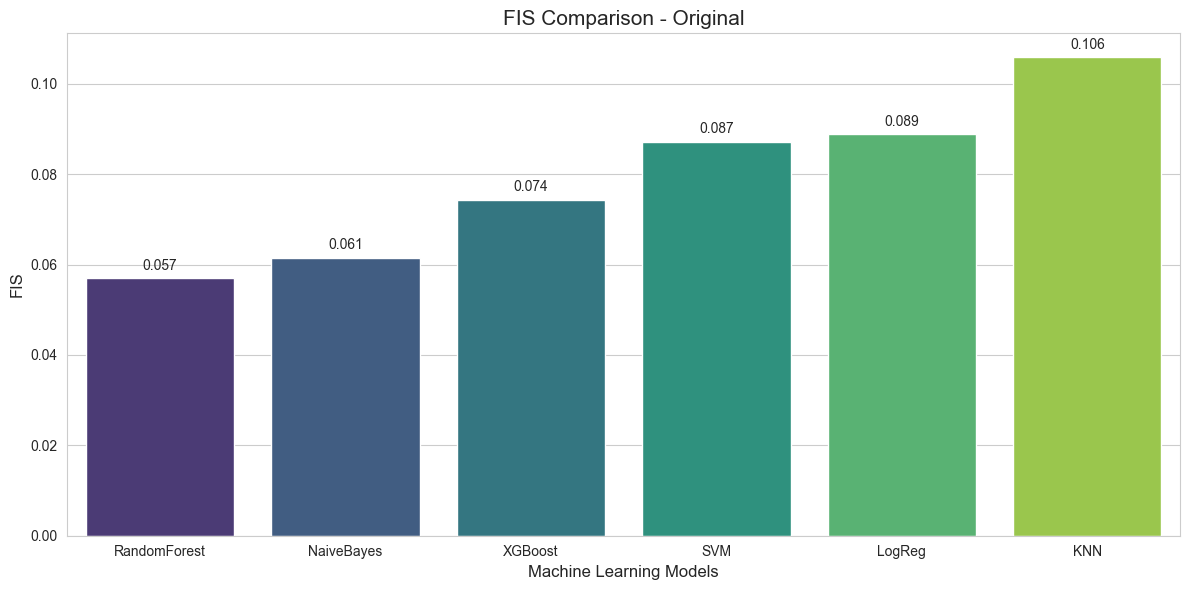

FIS Summary Table:
       Model    FIS
RandomForest 0.0570
  NaiveBayes 0.0615
     XGBoost 0.0744
         SVM 0.0873
      LogReg 0.0889
         KNN 0.1059


In [158]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_fis(spd, di, eod, aaod):
    spd_gap = abs(spd)
    di_gap = abs(1 - di)
    eod_gap = abs(eod)
    eo_gap = abs(aaod)

    parity_score = (spd_gap + di_gap) / 2
    error_fairness_score = (eod_gap + eo_gap) / 2
    
    fis = (0.5 * parity_score) + (0.5 * error_fairness_score)
    return fis

models_data = [
    {"Model": "LogReg", "SPD": SPD_orig_lr, "DI": DI_orig_lr, "EOD": EOD_orig_lr, "AAOD": AAOD_orig_lr},
    {"Model": "RandomForest", "SPD": SPD_orig_rf, "DI": DI_orig_rf, "EOD": EOD_orig_rf, "AAOD": AAOD_orig_rf},
    {"Model": "XGBoost", "SPD": SPD_orig_xgb, "DI": DI_orig_xgb, "EOD": EOD_orig_xgb, "AAOD": AAOD_orig_xgb},
    {"Model": "SVM", "SPD": SPD_orig_svm, "DI": DI_orig_svm, "EOD": EOD_orig_svm, "AAOD": AAOD_orig_svm},
    {"Model": "KNN", "SPD": SPD_orig_knn, "DI": DI_orig_knn, "EOD": EOD_orig_knn, "AAOD": AAOD_orig_knn},
    {"Model": "NaiveBayes", "SPD": SPD_orig_nb, "DI": DI_orig_nb, "EOD": EOD_orig_nb, "AAOD": AAOD_orig_nb}
]

def visualize_fis(models_data, title):
    df_fis = pd.DataFrame(models_data)
    df_fis['FIS'] = df_fis.apply(lambda x: calculate_fis(x['SPD'], x['DI'], x['EOD'], x['AAOD']), axis=1)

    df_fis = df_fis.sort_values('FIS')

    # 3. Create the Bar Chart
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    barplot = sns.barplot(x='Model', y='FIS', data=df_fis, hue='Model', palette='viridis', legend=False)

    plt.title(f'FIS Comparison - {title}', fontsize=15)
    plt.ylabel('FIS', fontsize=12)
    plt.xlabel('Machine Learning Models', fontsize=12)

    for p in barplot.patches:
        barplot.annotate(format(p.get_height(), '.3f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')

    plt.tight_layout()
    plt.show()

    df_fis['FIS'] = round(df_fis["FIS"], 4)
    print("FIS Summary Table:")
    print(df_fis[['Model', 'FIS']].to_string(index=False))

title = 'Original'
visualize_fis(models_data, title)

### Mean of results FIS Comparison (original result excluded)

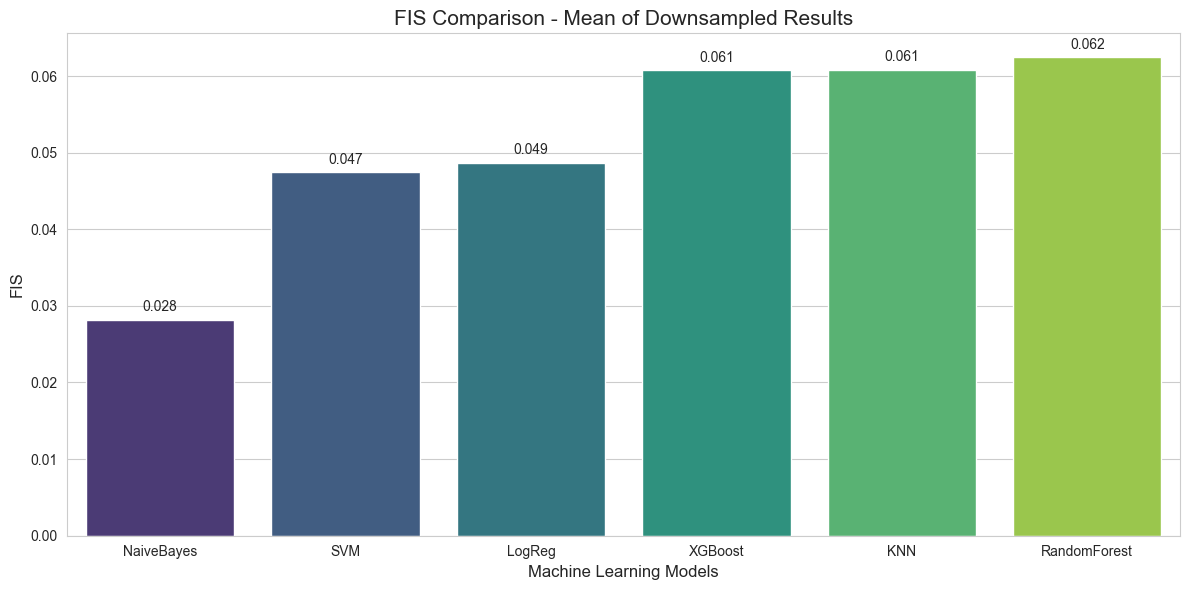

FIS Summary Table:
       Model    FIS
  NaiveBayes 0.0282
         SVM 0.0474
      LogReg 0.0486
     XGBoost 0.0607
         KNN 0.0608
RandomForest 0.0624


In [159]:
models_data_mean = [
    {"Model": "LogReg", "SPD": down_avg_spd_lr, "DI": down_avg_DI_lr, "EOD": down_avg_EOD_lr, "AAOD": down_avg_AAOD_lr},
    {"Model": "RandomForest", "SPD": down_avg_spd_rf, "DI": down_avg_DI_rf, "EOD": down_avg_EOD_rf, "AAOD": down_avg_AAOD_rf},
    {"Model": "XGBoost", "SPD": down_avg_spd_xgb, "DI": down_avg_DI_xgb, "EOD": down_avg_EOD_xgb, "AAOD": down_avg_AAOD_xgb},
    {"Model": "SVM", "SPD": down_avg_spd_svm, "DI": down_avg_DI_svm, "EOD": down_avg_EOD_svm, "AAOD": down_avg_AAOD_svm},
    {"Model": "KNN", "SPD": down_avg_spd_knn, "DI": down_avg_DI_knn, "EOD": down_avg_EOD_knn, "AAOD": down_avg_AAOD_knn},
    {"Model": "NaiveBayes", "SPD": down_avg_spd_nb, "DI": down_avg_DI_nb, "EOD": down_avg_EOD_nb, "AAOD": down_avg_AAOD_nb}
]

title = 'Mean of Downsampled Results'
visualize_fis(models_data_mean, title)

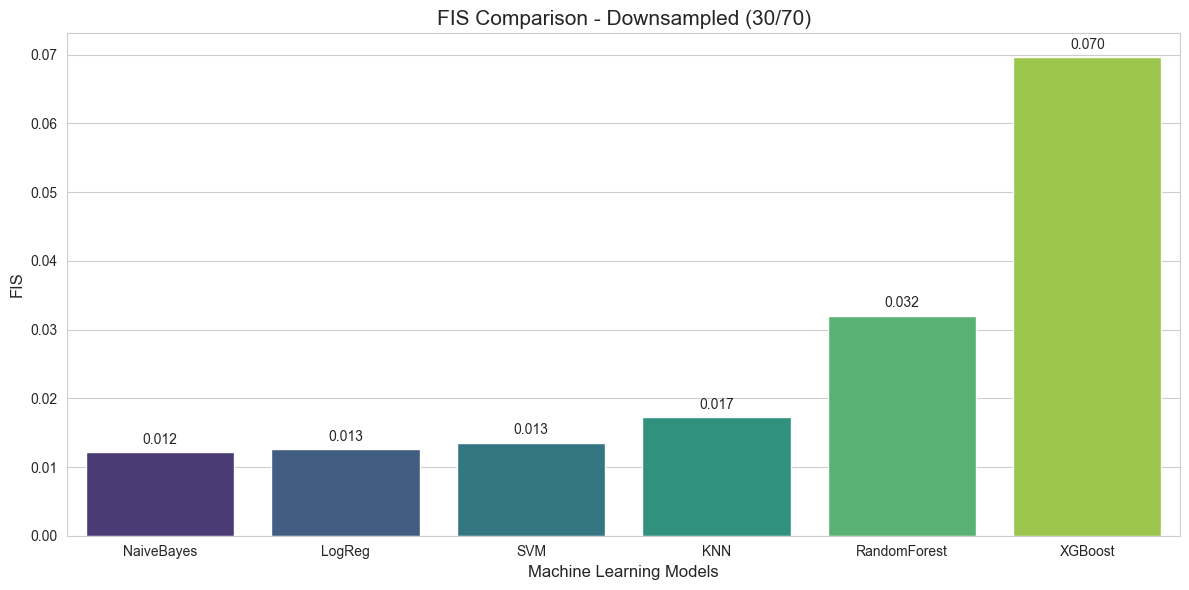

FIS Summary Table:
       Model    FIS
  NaiveBayes 0.0122
      LogReg 0.0126
         SVM 0.0135
         KNN 0.0172
RandomForest 0.0320
     XGBoost 0.0696


In [160]:
models_data_30 = [
    {"Model": "LogReg", "SPD": SPD_orig_lr2, "DI": DI_orig_lr2, "EOD": EOD_orig_lr2, "AAOD": AAOD_orig_lr2},
    {"Model": "RandomForest", "SPD": SPD_orig_rf2, "DI": DI_orig_rf2, "EOD": EOD_orig_rf2, "AAOD": AAOD_orig_rf2},
    {"Model": "XGBoost", "SPD": SPD_orig_xgb2, "DI": DI_orig_xgb2, "EOD": EOD_orig_xgb2, "AAOD": AAOD_orig_xgb2},
    {"Model": "SVM", "SPD": SPD_orig_svm2, "DI": DI_orig_svm2, "EOD": EOD_orig_svm2, "AAOD": AAOD_orig_svm2},
    {"Model": "KNN", "SPD": SPD_orig_knn2, "DI": DI_orig_knn2, "EOD": EOD_orig_knn2, "AAOD": AAOD_orig_knn2},
    {"Model": "NaiveBayes", "SPD": SPD_orig_nb2, "DI": DI_orig_nb2, "EOD": EOD_orig_nb2, "AAOD": AAOD_orig_nb2}
]

title = 'Downsampled (30/70)'
visualize_fis(models_data_30, title)

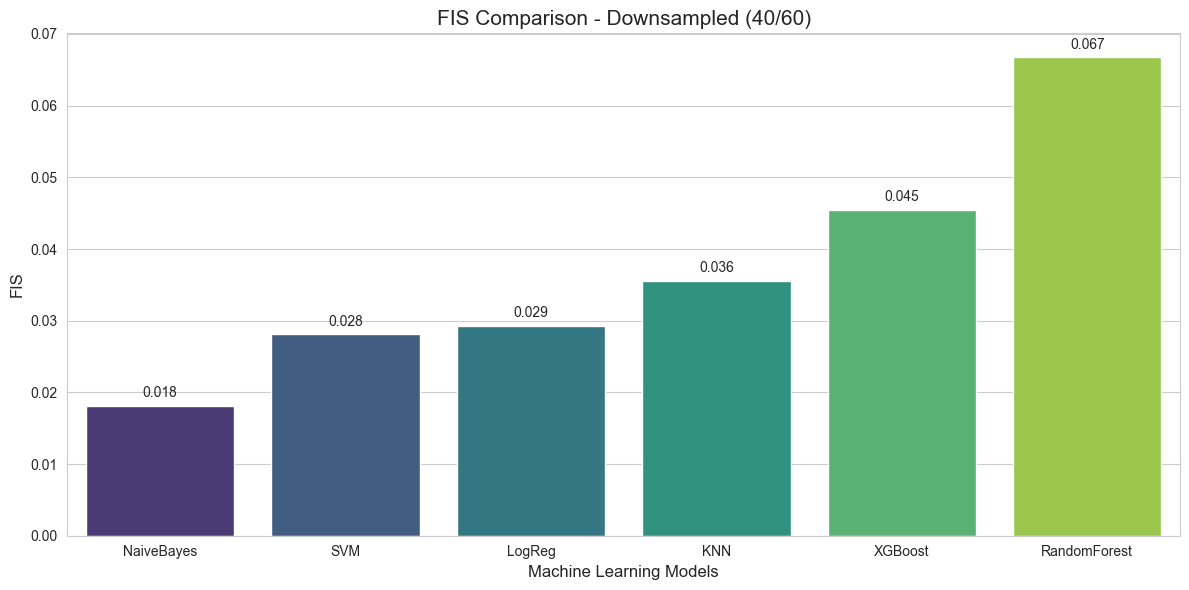

FIS Summary Table:
       Model    FIS
  NaiveBayes 0.0181
         SVM 0.0281
      LogReg 0.0293
         KNN 0.0356
     XGBoost 0.0455
RandomForest 0.0668


In [161]:
models_data_40 = [
    {"Model": "LogReg", "SPD": SPD_orig_lr3, "DI": DI_orig_lr3, "EOD": EOD_orig_lr3, "AAOD": AAOD_orig_lr3},
    {"Model": "RandomForest", "SPD": SPD_orig_rf3, "DI": DI_orig_rf3, "EOD": EOD_orig_rf3, "AAOD": AAOD_orig_rf3},
    {"Model": "XGBoost", "SPD": SPD_orig_xgb3, "DI": DI_orig_xgb3, "EOD": EOD_orig_xgb3, "AAOD": AAOD_orig_xgb3},
    {"Model": "SVM", "SPD": SPD_orig_svm3, "DI": DI_orig_svm3, "EOD": EOD_orig_svm3, "AAOD": AAOD_orig_svm3},
    {"Model": "KNN", "SPD": SPD_orig_knn3, "DI": DI_orig_knn3, "EOD": EOD_orig_knn3, "AAOD": AAOD_orig_knn3},
    {"Model": "NaiveBayes", "SPD": SPD_orig_nb3, "DI": DI_orig_nb3, "EOD": EOD_orig_nb3, "AAOD": AAOD_orig_nb3}
]

title = 'Downsampled (40/60)'
visualize_fis(models_data_40, title)

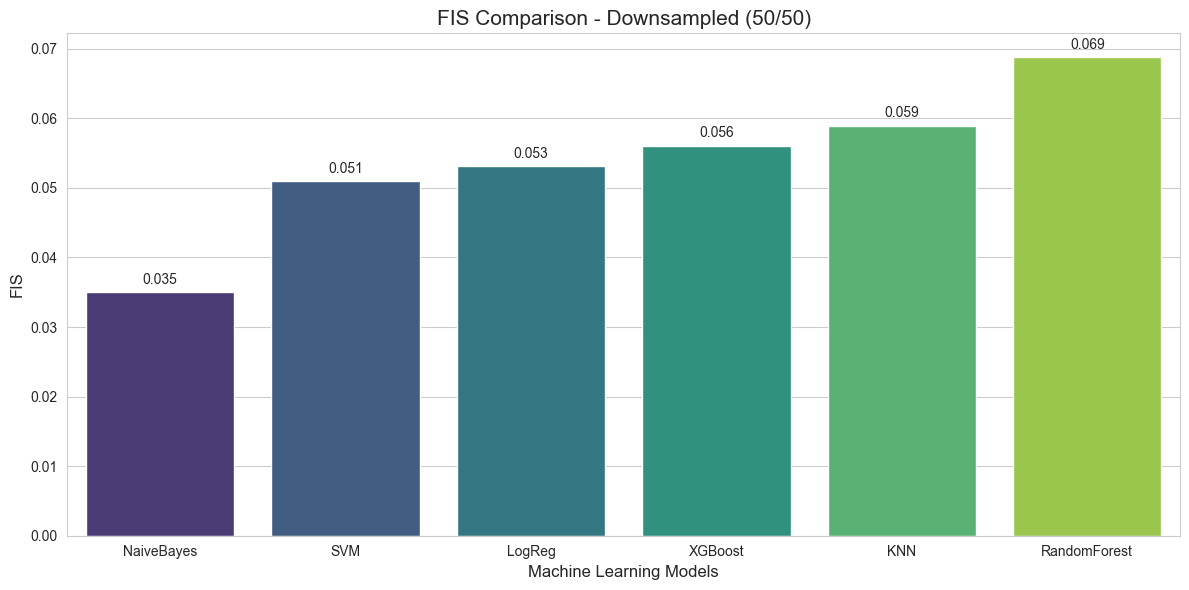

FIS Summary Table:
       Model    FIS
  NaiveBayes 0.0350
         SVM 0.0510
      LogReg 0.0531
     XGBoost 0.0560
         KNN 0.0589
RandomForest 0.0688


In [162]:
models_data_50 = [
    {"Model": "LogReg", "SPD": SPD_orig_lr4, "DI": DI_orig_lr4, "EOD": EOD_orig_lr4, "AAOD": AAOD_orig_lr4},
    {"Model": "RandomForest", "SPD": SPD_orig_rf4, "DI": DI_orig_rf4, "EOD": EOD_orig_rf4, "AAOD": AAOD_orig_rf4},
    {"Model": "XGBoost", "SPD": SPD_orig_xgb4, "DI": DI_orig_xgb4, "EOD": EOD_orig_xgb4, "AAOD": AAOD_orig_xgb4},
    {"Model": "SVM", "SPD": SPD_orig_svm4, "DI": DI_orig_svm4, "EOD": EOD_orig_svm4, "AAOD": AAOD_orig_svm4},
    {"Model": "KNN", "SPD": SPD_orig_knn4, "DI": DI_orig_knn4, "EOD": EOD_orig_knn4, "AAOD": AAOD_orig_knn4},
    {"Model": "NaiveBayes", "SPD": SPD_orig_nb4, "DI": DI_orig_nb4, "EOD": EOD_orig_nb4, "AAOD": AAOD_orig_nb4}
]

title = 'Downsampled (50/50)'
visualize_fis(models_data_50, title)

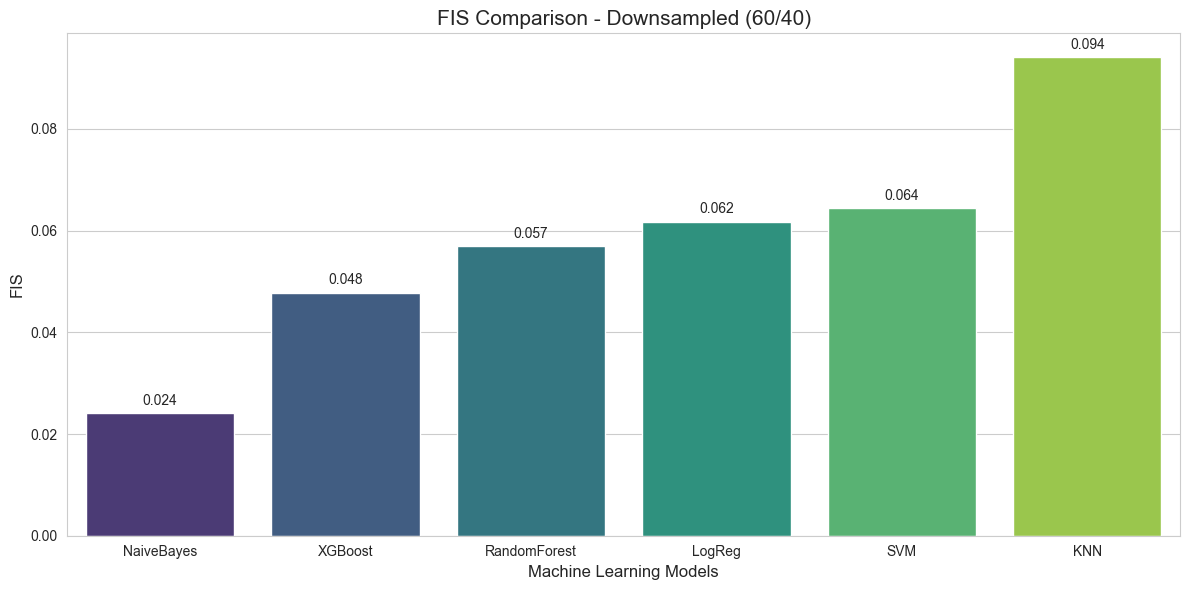

FIS Summary Table:
       Model    FIS
  NaiveBayes 0.0241
     XGBoost 0.0478
RandomForest 0.0569
      LogReg 0.0618
         SVM 0.0644
         KNN 0.0941


In [163]:
models_data_60 = [
    {"Model": "LogReg", "SPD": SPD_orig_lr5, "DI": DI_orig_lr5, "EOD": EOD_orig_lr5, "AAOD": AAOD_orig_lr5},
    {"Model": "RandomForest", "SPD": SPD_orig_rf5, "DI": DI_orig_rf5, "EOD": EOD_orig_rf5, "AAOD": AAOD_orig_rf5},
    {"Model": "XGBoost", "SPD": SPD_orig_xgb5, "DI": DI_orig_xgb5, "EOD": EOD_orig_xgb5, "AAOD": AAOD_orig_xgb5},
    {"Model": "SVM", "SPD": SPD_orig_svm5, "DI": DI_orig_svm5, "EOD": EOD_orig_svm5, "AAOD": AAOD_orig_svm5},
    {"Model": "KNN", "SPD": SPD_orig_knn5, "DI": DI_orig_knn5, "EOD": EOD_orig_knn5, "AAOD": AAOD_orig_knn5},
    {"Model": "NaiveBayes", "SPD": SPD_orig_nb5, "DI": DI_orig_nb5, "EOD": EOD_orig_nb5, "AAOD": AAOD_orig_nb5}
]

title = 'Downsampled (60/40)'
visualize_fis(models_data_60, title)

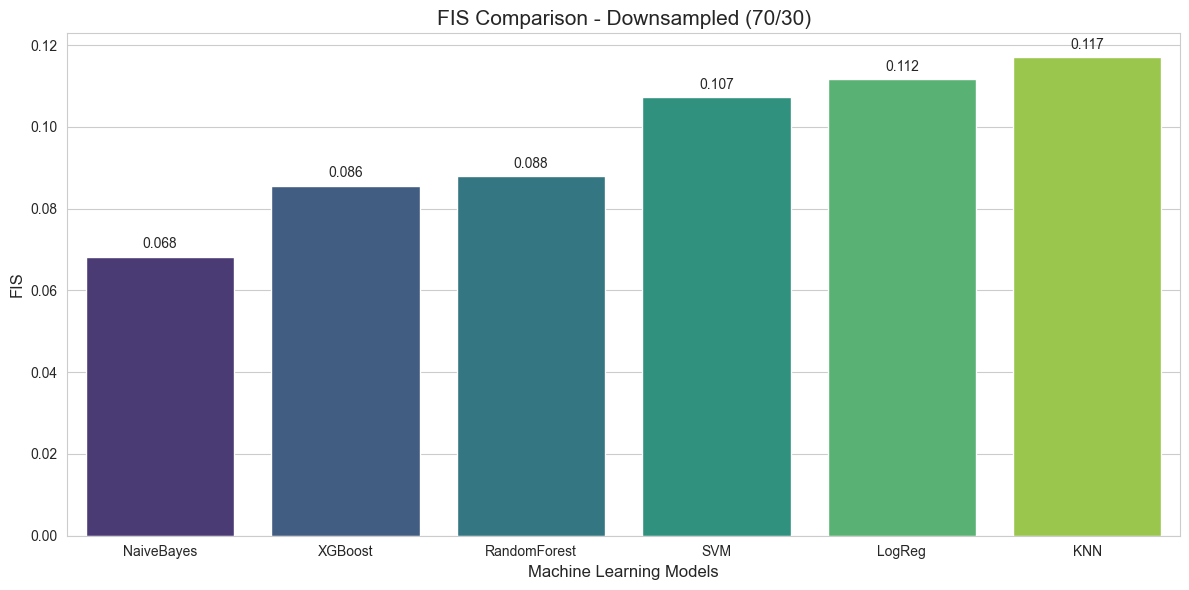

FIS Summary Table:
       Model    FIS
  NaiveBayes 0.0683
     XGBoost 0.0856
RandomForest 0.0879
         SVM 0.1072
      LogReg 0.1117
         KNN 0.1170


In [164]:
models_data_70 = [
    {"Model": "LogReg", "SPD": SPD_orig_lr6, "DI": DI_orig_lr6, "EOD": EOD_orig_lr6, "AAOD": AAOD_orig_lr6},
    {"Model": "RandomForest", "SPD": SPD_orig_rf6, "DI": DI_orig_rf6, "EOD": EOD_orig_rf6, "AAOD": AAOD_orig_rf6},
    {"Model": "XGBoost", "SPD": SPD_orig_xgb6, "DI": DI_orig_xgb6, "EOD": EOD_orig_xgb6, "AAOD": AAOD_orig_xgb6},
    {"Model": "SVM", "SPD": SPD_orig_svm6, "DI": DI_orig_svm6, "EOD": EOD_orig_svm6, "AAOD": AAOD_orig_svm6},
    {"Model": "KNN", "SPD": SPD_orig_knn6, "DI": DI_orig_knn6, "EOD": EOD_orig_knn6, "AAOD": AAOD_orig_knn6},
    {"Model": "NaiveBayes", "SPD": SPD_orig_nb6, "DI": DI_orig_nb6, "EOD": EOD_orig_nb6, "AAOD": AAOD_orig_nb6}
]

title = 'Downsampled (70/30)'
visualize_fis(models_data_70, title)

# Oversampled

In [165]:
fixed_total_over = int(len(df_male) / 0.30)
def get_oversampled_df(df_male, df_female, target_male_percent):    
    n_males_needed = int(fixed_total_over * target_male_percent)
    n_females_needed = fixed_total_over - n_males_needed
    df_m = df_male.sample(n=n_males_needed, replace=(n_males_needed > len(df_male)), random_state=42)
    df_f = df_female.sample(n=n_females_needed, replace=True, random_state=42)

    return pd.concat([df_m, df_f]).sample(frac=1, random_state=42)

df_30_70_up = get_oversampled_df(df_male, df_female, 0.30)
df_40_60_up = get_oversampled_df(df_male, df_female, 0.40)
df_50_50_up = get_oversampled_df(df_male, df_female, 0.50)
df_60_40_up = get_oversampled_df(df_male, df_female, 0.60)
df_70_30_up = get_oversampled_df(df_male, df_female, 0.70)

print(f"30/70 Set: {df_30_70_up['Gender'].value_counts()}")
print(f"40/60 Set: {df_40_60_up['Gender'].value_counts()}")
print(f"50/50 Set: {df_50_50_up['Gender'].value_counts()}")
print(f"60/40 Set: {df_60_40_up['Gender'].value_counts()}")
print(f"70/30 Set: {df_70_30_up['Gender'].value_counts()}")

30/70 Set: Gender
0    159873
1     68517
Name: count, dtype: int64
40/60 Set: Gender
0    137034
1     91356
Name: count, dtype: int64
50/50 Set: Gender
1    114195
0    114195
Name: count, dtype: int64
60/40 Set: Gender
1    137034
0     91356
Name: count, dtype: int64
70/30 Set: Gender
1    159873
0     68517
Name: count, dtype: int64


In [166]:
dfs = {"orig": df, "50_50": df_50_50_up, "60_40": df_60_40_up, "70_30": df_70_30_up, "30_70": df_30_70_up, "40_60": df_40_60_up}
X_y_pairs = {name: (d.drop(columns=['Employed']), d['Employed']) for name, d in dfs.items()}

In [167]:
scaler = StandardScaler()
# --- Original data block ---
X_orig, y_orig = X_y_pairs["orig"]
gender_orig = X_orig['Gender']

X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
    X_orig, y_orig, gender_orig, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 30/70 data block ---
X_30, y_30 = X_y_pairs["30_70"]
gender_30 = X_30['Gender']

X_train2, X_test2, y_train2, y_test2, gender_train2, gender_test2 = train_test_split(
    X_30, y_30, gender_30, test_size=0.2, random_state=42)

X_train_scaled2 = scaler.fit_transform(X_train2)
X_test_scaled2 = scaler.transform(X_test2)

# --- 40/60 data block ---
X_40, y_40 = X_y_pairs["40_60"]
gender_40 = X_40['Gender']

X_train3, X_test3, y_train3, y_test3, gender_train3, gender_test3 = train_test_split(
    X_40, y_40, gender_40, test_size=0.2, random_state=42)

X_train_scaled3 = scaler.fit_transform(X_train3)
X_test_scaled3 = scaler.transform(X_test3)

# --- 50/50 data block ---
X_50, y_50 = X_y_pairs["50_50"]
gender_50 = X_50['Gender']

X_train4, X_test4, y_train4, y_test4, gender_train4, gender_test4 = train_test_split(
    X_50, y_50, gender_50, test_size=0.2, random_state=42)

X_train_scaled4 = scaler.fit_transform(X_train4)
X_test_scaled4 = scaler.transform(X_test4)

# --- 60/40 data block ---
X_60, y_60 = X_y_pairs["60_40"]
gender_60 = X_60['Gender']

X_train5, X_test5, y_train5, y_test5, gender_train5, gender_test5 = train_test_split(
    X_60, y_60, gender_60, test_size=0.2, random_state=42)

X_train_scaled5 = scaler.fit_transform(X_train5)
X_test_scaled5 = scaler.transform(X_test5)

# --- 70/30 data block ---
X_70, y_70 = X_y_pairs["70_30"]
gender_70 = X_70['Gender']

X_train6, X_test6, y_train6, y_test6, gender_train6, gender_test6 = train_test_split(
    X_70, y_70, gender_70, test_size=0.2, random_state=42)

X_train_scaled6 = scaler.fit_transform(X_train6)
X_test_scaled6 = scaler.transform(X_test6)

In [168]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42).fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
sp_lr, TPR_lr, FPR_lr, gender_acc_lr, model_acc_lr = evaluate_fairness(y_test, y_pred_lr, "Logistic Regression", gender_test)

lr_model2 = LogisticRegression(random_state=42).fit(X_train_scaled2, y_train2)
y_pred_lr2 = lr_model2.predict(X_test_scaled2)
sp_lr2, TPR_lr2, FPR_lr2, gender_acc_lr2, model_acc_lr2 = evaluate_fairness(y_test2, y_pred_lr2, "Logistic Regression (30/70)", gender_test2)

lr_model3 = LogisticRegression(random_state=42).fit(X_train_scaled3, y_train3)
y_pred_lr3 = lr_model3.predict(X_test_scaled3)
sp_lr3, TPR_lr3, FPR_lr3, gender_acc_lr3, model_acc_lr3 = evaluate_fairness(y_test3, y_pred_lr3, "Logistic Regression (40/60)", gender_test3)

lr_model4 = LogisticRegression(random_state=42).fit(X_train_scaled4, y_train4)
y_pred_lr4 = lr_model4.predict(X_test_scaled4)
sp_lr4, TPR_lr4, FPR_lr4, gender_acc_lr4, model_acc_lr4 = evaluate_fairness(y_test4, y_pred_lr4, "Logistic Regression (50/50)", gender_test4)

lr_model5 = LogisticRegression(random_state=42).fit(X_train_scaled5, y_train5)
y_pred_lr5 = lr_model5.predict(X_test_scaled5)
sp_lr5, TPR_lr5, FPR_lr5, gender_acc_lr5, model_acc_lr5 = evaluate_fairness(y_test5, y_pred_lr5, "Logistic Regression (60/40)", gender_test5)

lr_model6 = LogisticRegression(random_state=42).fit(X_train_scaled6, y_train6)
y_pred_lr6 = lr_model6.predict(X_test_scaled6)
sp_lr6, TPR_lr6, FPR_lr6, gender_acc_lr6, model_acc_lr6 = evaluate_fairness(y_test6, y_pred_lr6, "Logistic Regression (70/30)", gender_test6)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
sp_rf, TPR_rf, FPR_rf, gender_acc_rf, model_acc_rf = evaluate_fairness(y_test, y_pred_rf, "Random Forest", gender_test)

rf_model2 = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_scaled2, y_train2)
y_pred_rf2 = rf_model2.predict(X_test_scaled2)
sp_rf2, TPR_rf2, FPR_rf2, gender_acc_rf2, model_acc_rf2 = evaluate_fairness(y_test2, y_pred_rf2, "Random Forest (30/70)", gender_test2)

rf_model3 = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_scaled3, y_train3)
y_pred_rf3 = rf_model3.predict(X_test_scaled3)
sp_rf3, TPR_rf3, FPR_rf3, gender_acc_rf3, model_acc_rf3 = evaluate_fairness(y_test3, y_pred_rf3, "Random Forest (40/60)", gender_test3)

rf_model4 = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_scaled4, y_train4)
y_pred_rf4 = rf_model4.predict(X_test_scaled4)
sp_rf4, TPR_rf4, FPR_rf4, gender_acc_rf4, model_acc_rf4 = evaluate_fairness(y_test4, y_pred_rf4, "Random Forest (50/50)", gender_test4)

rf_model5 = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_scaled5, y_train5)
y_pred_rf5 = rf_model5.predict(X_test_scaled5)
sp_rf5, TPR_rf5, FPR_rf5, gender_acc_rf5, model_acc_rf5 = evaluate_fairness(y_test5, y_pred_rf5, "Random Forest (60/40)", gender_test5)

rf_model6 = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_scaled6, y_train6)
y_pred_rf6 = rf_model6.predict(X_test_scaled6)
sp_rf6, TPR_rf6, FPR_rf6, gender_acc_rf6, model_acc_rf6 = evaluate_fairness(y_test6, y_pred_rf6, "Random Forest (70/30)", gender_test6)

'''
# Gradient Boosting
gbc = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42).fit(X_train_scaled, y_train)
y_pred_gbc = gbc.predict(X_test_scaled)
sp_gbc, TPR_gbc, FPR_gbc, gender_acc_gbc, model_acc_gbc= evaluate_fairness(y_test, y_pred_gbc, "Gradient Boosting")
'''

#XGBoost
xgb = XGBClassifier(n_estimators=300, random_state=42).fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
sp_xgb, TPR_xgb, FPR_xgb, gender_acc_xgb, model_acc_xgb = evaluate_fairness(y_test, y_pred_xgb, "XGBoost", gender_test)

xgb2 = XGBClassifier(n_estimators=300, random_state=42).fit(X_train_scaled2, y_train2)
y_pred_xgb2 = xgb2.predict(X_test_scaled2)
sp_xgb2, TPR_xgb2, FPR_xgb2, gender_acc_xgb2, model_acc_xgb2 = evaluate_fairness(y_test2, y_pred_xgb2, "XGBoost (30/70)", gender_test2)

xgb3 = XGBClassifier(n_estimators=300, random_state=42).fit(X_train_scaled3, y_train3)
y_pred_xgb3 = xgb3.predict(X_test_scaled3)
sp_xgb3, TPR_xgb3, FPR_xgb3, gender_acc_xgb3, model_acc_xgb3 = evaluate_fairness(y_test3, y_pred_xgb3, "XGBoost (40/60)", gender_test3)

xgb4 = XGBClassifier(n_estimators=300, random_state=42).fit(X_train_scaled4, y_train4)
y_pred_xgb4 = xgb4.predict(X_test_scaled4)
sp_xgb4, TPR_xgb4, FPR_xgb4, gender_acc_xgb4, model_acc_xgb4 = evaluate_fairness(y_test4, y_pred_xgb4, "XGBoost (50/50)", gender_test4)

xgb5 = XGBClassifier(n_estimators=300, random_state=42).fit(X_train_scaled5, y_train5)
y_pred_xgb5 = xgb5.predict(X_test_scaled5)
sp_xgb5, TPR_xgb5, FPR_xgb5, gender_acc_xgb5, model_acc_xgb5 = evaluate_fairness(y_test5, y_pred_xgb5, "XGBoost (60/40)", gender_test5)

xgb6 = XGBClassifier(n_estimators=300, random_state=42).fit(X_train_scaled6, y_train6)
y_pred_xgb6 = xgb6.predict(X_test_scaled6)
sp_xgb6, TPR_xgb6, FPR_xgb6, gender_acc_xgb6, model_acc_xgb6 = evaluate_fairness(y_test6, y_pred_xgb6, "XGBoost (70/30)", gender_test6)

#SVM
svm = LinearSVC(random_state=42, dual=False).fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
sp_svm, TPR_svm, FPR_svm, gender_acc_svm, model_acc_svm = evaluate_fairness(y_test, y_pred_svm, "SVM", gender_test)

svm2 = LinearSVC(random_state=42, dual=False).fit(X_train_scaled2, y_train2)
y_pred_svm2 = svm2.predict(X_test_scaled2)
sp_svm2, TPR_svm2, FPR_svm2, gender_acc_svm2, model_acc_svm2 = evaluate_fairness(y_test2, y_pred_svm2, "SVM (30/70)", gender_test2)

svm3 = LinearSVC(random_state=42, dual=False).fit(X_train_scaled3, y_train3)
y_pred_svm3 = svm3.predict(X_test_scaled3)
sp_svm3, TPR_svm3, FPR_svm3, gender_acc_svm3, model_acc_svm3 = evaluate_fairness(y_test3, y_pred_svm3, "SVM (40/60)", gender_test3)

svm4 = LinearSVC(random_state=42, dual=False).fit(X_train_scaled4, y_train4)
y_pred_svm4 = svm4.predict(X_test_scaled4)
sp_svm4, TPR_svm4, FPR_svm4, gender_acc_svm4, model_acc_svm4 = evaluate_fairness(y_test4, y_pred_svm4, "SVM (50/50)", gender_test4)

svm5 = LinearSVC(random_state=42, dual=False).fit(X_train_scaled5, y_train5)
y_pred_svm5 = svm5.predict(X_test_scaled5)
sp_svm5, TPR_svm5, FPR_svm5, gender_acc_svm5, model_acc_svm5 = evaluate_fairness(y_test5, y_pred_svm5, "SVM (60/40)", gender_test5)

svm6 = LinearSVC(random_state=42, dual=False).fit(X_train_scaled6, y_train6)
y_pred_svm6 = svm6.predict(X_test_scaled6)
sp_svm6, TPR_svm6, FPR_svm6, gender_acc_svm6, model_acc_svm6 = evaluate_fairness(y_test6, y_pred_svm6, "SVM (70/30)", gender_test6)

#KNN
knn = KNeighborsClassifier(n_neighbors=17).fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
sp_knn, TPR_knn, FPR_knn, gender_acc_knn, model_acc_knn = evaluate_fairness(y_test, y_pred_knn, "KNN", gender_test)

knn2 = KNeighborsClassifier(n_neighbors=17).fit(X_train_scaled2, y_train2)
y_pred_knn2 = knn2.predict(X_test_scaled2)
sp_knn2, TPR_knn2, FPR_knn2, gender_acc_knn2, model_acc_knn2 = evaluate_fairness(y_test2, y_pred_knn2, "KNN (30/70)", gender_test2)

knn3 = KNeighborsClassifier(n_neighbors=17).fit(X_train_scaled3, y_train3)
y_pred_knn3 = knn3.predict(X_test_scaled3)
sp_knn3, TPR_knn3, FPR_knn3, gender_acc_knn3, model_acc_knn3 = evaluate_fairness(y_test3, y_pred_knn3, "KNN (40/60)", gender_test3)

knn4 = KNeighborsClassifier(n_neighbors=17).fit(X_train_scaled4, y_train4)
y_pred_knn4 = knn4.predict(X_test_scaled4)
sp_knn4, TPR_knn4, FPR_knn4, gender_acc_knn4, model_acc_knn4 = evaluate_fairness(y_test4, y_pred_knn4, "KNN (50/50)", gender_test4)

knn5 = KNeighborsClassifier(n_neighbors=17).fit(X_train_scaled5, y_train5)
y_pred_knn5 = knn5.predict(X_test_scaled5)
sp_knn5, TPR_knn5, FPR_knn5, gender_acc_knn5, model_acc_knn5 = evaluate_fairness(y_test5, y_pred_knn5, "KNN (60/40)", gender_test5)

knn6 = KNeighborsClassifier(n_neighbors=17).fit(X_train_scaled6, y_train6)
y_pred_knn6 = knn6.predict(X_test_scaled6)
sp_knn6, TPR_knn6, FPR_knn6, gender_acc_knn6, model_acc_knn6 = evaluate_fairness(y_test6, y_pred_knn6, "KNN (70/30)", gender_test6)

#Naive bayes
nb = GaussianNB().fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
sp_nb, TPR_nb, FPR_nb, gender_acc_nb, model_acc_nb = evaluate_fairness(y_test, y_pred_nb, "Naive Bayes", gender_test)

nb2 = GaussianNB().fit(X_train2, y_train2)
y_pred_nb2 = nb2.predict(X_test2)
sp_nb2, TPR_nb2, FPR_nb2, gender_acc_nb2, model_acc_nb2 = evaluate_fairness(y_test2, y_pred_nb2, "Naive Bayes (30/70)", gender_test2)

nb3 = GaussianNB().fit(X_train3, y_train3)
y_pred_nb3 = nb3.predict(X_test3)
sp_nb3, TPR_nb3, FPR_nb3, gender_acc_nb3, model_acc_nb3 = evaluate_fairness(y_test3, y_pred_nb3, "Naive Bayes (40/60)", gender_test3)

nb4 = GaussianNB().fit(X_train4, y_train4)
y_pred_nb4 = nb4.predict(X_test4)
sp_nb4, TPR_nb4, FPR_nb4, gender_acc_nb4, model_acc_nb4 = evaluate_fairness(y_test4, y_pred_nb4, "Naive Bayes (50/50)", gender_test4)

nb5 = GaussianNB().fit(X_train5, y_train5)
y_pred_nb5 = nb5.predict(X_test5)
sp_nb5, TPR_nb5, FPR_nb5, gender_acc_nb5, model_acc_nb5 = evaluate_fairness(y_test5, y_pred_nb5, "Naive Bayes (60/40)", gender_test5)

nb6 = GaussianNB().fit(X_train6, y_train6)
y_pred_nb6 = nb6.predict(X_test6)
sp_nb6, TPR_nb6, FPR_nb6, gender_acc_nb6, model_acc_nb6 = evaluate_fairness(y_test6, y_pred_nb6, "Naive Bayes (70/30)", gender_test6)

In [169]:
# Logistic Regression
print(f"Logistic Regression Mean Metrics:\n- Overall Accuracy: {round(np.mean([model_acc_lr2, model_acc_lr3, model_acc_lr4, model_acc_lr5, model_acc_lr6]), 4)}\n- Female Accuracy:  {round(np.mean([acc[0] for acc in [gender_acc_lr2, gender_acc_lr3, gender_acc_lr4, gender_acc_lr5, gender_acc_lr6]]), 4)}\n- Male Accuracy:    {round(np.mean([acc[1] for acc in [gender_acc_lr2, gender_acc_lr3, gender_acc_lr4, gender_acc_lr5, gender_acc_lr6]]), 4)}\n")

# Random Forest
print(f"Random Forest Mean Metrics:\n- Overall Accuracy: {round(np.mean([model_acc_rf2, model_acc_rf3, model_acc_rf4, model_acc_rf5, model_acc_rf6]), 4)}\n- Female Accuracy:  {round(np.mean([acc[0] for acc in [gender_acc_rf2, gender_acc_rf3, gender_acc_rf4, gender_acc_rf5, gender_acc_rf6]]), 4)}\n- Male Accuracy:    {round(np.mean([acc[1] for acc in [gender_acc_rf2, gender_acc_rf3, gender_acc_rf4, gender_acc_rf5, gender_acc_rf6]]), 4)}\n")

# XGBoost
print(f"XGBoost Mean Metrics:\n- Overall Accuracy: {round(np.mean([model_acc_xgb2, model_acc_xgb3, model_acc_xgb4, model_acc_xgb5, model_acc_xgb6]), 4)}\n- Female Accuracy:  {round(np.mean([acc[0] for acc in [gender_acc_xgb2, gender_acc_xgb3, gender_acc_xgb4, gender_acc_xgb5, gender_acc_xgb6]]), 4)}\n- Male Accuracy:    {round(np.mean([acc[1] for acc in [gender_acc_xgb2, gender_acc_xgb3, gender_acc_xgb4, gender_acc_xgb5, gender_acc_xgb6]]), 4)}\n")

# SVM
print(f"SVM Mean Metrics:\n- Overall Accuracy: {round(np.mean([model_acc_svm2, model_acc_svm3, model_acc_svm4, model_acc_svm5, model_acc_svm6]), 4)}\n- Female Accuracy:  {round(np.mean([acc[0] for acc in [gender_acc_svm2, gender_acc_svm3, gender_acc_svm4, gender_acc_svm5, gender_acc_svm6]]), 4)}\n- Male Accuracy:    {round(np.mean([acc[1] for acc in [gender_acc_svm2, gender_acc_svm3, gender_acc_svm4, gender_acc_svm5, gender_acc_svm6]]), 4)}\n")

# KNN
print(f"KNN Mean Metrics:\n- Overall Accuracy: {round(np.mean([model_acc_knn2, model_acc_knn3, model_acc_knn4, model_acc_knn5, model_acc_knn6]), 4)}\n- Female Accuracy:  {round(np.mean([acc[0] for acc in [gender_acc_knn2, gender_acc_knn3, gender_acc_knn4, gender_acc_knn5, gender_acc_knn6]]), 4)}\n- Male Accuracy:    {round(np.mean([acc[1] for acc in [gender_acc_knn2, gender_acc_knn3, gender_acc_knn4, gender_acc_knn5, gender_acc_knn6]]), 4)}\n")

# Naive Bayes
print(f"Naive Bayes Mean Metrics:\n- Overall Accuracy: {round(np.mean([model_acc_nb2, model_acc_nb3, model_acc_nb4, model_acc_nb5, model_acc_nb6]), 4)}\n- Female Accuracy:  {round(np.mean([acc[0] for acc in [gender_acc_nb2, gender_acc_nb3, gender_acc_nb4, gender_acc_nb5, gender_acc_nb6]]), 4)}\n- Male Accuracy:    {round(np.mean([acc[1] for acc in [gender_acc_nb2, gender_acc_nb3, gender_acc_nb4, gender_acc_nb5, gender_acc_nb6]]), 4)}\n")

Logistic Regression Mean Metrics:
- Overall Accuracy: 0.7888
- Female Accuracy:  0.793
- Male Accuracy:    0.7842

Random Forest Mean Metrics:
- Overall Accuracy: 0.9559
- Female Accuracy:  1.0
- Male Accuracy:    0.8938

XGBoost Mean Metrics:
- Overall Accuracy: 0.8913
- Female Accuracy:  0.9748
- Male Accuracy:    0.8001

SVM Mean Metrics:
- Overall Accuracy: 0.788
- Female Accuracy:  0.7923
- Male Accuracy:    0.783

KNN Mean Metrics:
- Overall Accuracy: 0.8912
- Female Accuracy:  0.9869
- Male Accuracy:    0.7888

Naive Bayes Mean Metrics:
- Overall Accuracy: 0.7704
- Female Accuracy:  0.7711
- Male Accuracy:    0.7689



# Statistical Parity Difference
### $$SPD = Pr(\hat{Y} = 1 \mid D = \text{unprivileged}) - Pr(\hat{Y} = 1 \mid D = \text{privileged})$$

In [170]:
SPD_orig_lr, SPD_orig_lr2, SPD_orig_lr3, SPD_orig_lr4, SPD_orig_lr5, SPD_orig_lr6 = [round(s[0] - s[1], 4) for s in [sp_lr, sp_lr2, sp_lr3, sp_lr4, sp_lr5, sp_lr6]]
SPD_orig_rf, SPD_orig_rf2, SPD_orig_rf3, SPD_orig_rf4, SPD_orig_rf5, SPD_orig_rf6 = [round(s[0] - s[1], 4) for s in [sp_rf, sp_rf2, sp_rf3, sp_rf4, sp_rf5, sp_rf6]]
SPD_orig_xgb, SPD_orig_xgb2, SPD_orig_xgb3, SPD_orig_xgb4, SPD_orig_xgb5, SPD_orig_xgb6 = [round(s[0] - s[1], 4) for s in [sp_xgb, sp_xgb2, sp_xgb3, sp_xgb4, sp_xgb5, sp_xgb6]]
SPD_orig_svm, SPD_orig_svm2, SPD_orig_svm3, SPD_orig_svm4, SPD_orig_svm5, SPD_orig_svm6 = [round(s[0] - s[1], 4) for s in [sp_svm, sp_svm2, sp_svm3, sp_svm4, sp_svm5, sp_svm6]]
SPD_orig_knn, SPD_orig_knn2, SPD_orig_knn3, SPD_orig_knn4, SPD_orig_knn5, SPD_orig_knn6 = [round(s[0] - s[1], 4) for s in [sp_knn, sp_knn2, sp_knn3, sp_knn4, sp_knn5, sp_knn6]]
SPD_orig_nb, SPD_orig_nb2, SPD_orig_nb3, SPD_orig_nb4, SPD_orig_nb5, SPD_orig_nb6 = [round(s[0] - s[1], 4) for s in [sp_nb, sp_nb2, sp_nb3, sp_nb4, sp_nb5, sp_nb6]]
over_avg_spd_lr = round(np.mean([SPD_orig_lr2, SPD_orig_lr3, SPD_orig_lr4, SPD_orig_lr5, SPD_orig_lr6]), 4)  # Original testing result excluded 
over_avg_spd_rf = round(np.mean([SPD_orig_rf2, SPD_orig_rf3, SPD_orig_rf4, SPD_orig_rf5, SPD_orig_rf6]), 4)
over_avg_spd_xgb = round(np.mean([SPD_orig_xgb2, SPD_orig_xgb3, SPD_orig_xgb4, SPD_orig_xgb5, SPD_orig_xgb6]), 4)
over_avg_spd_svm = round(np.mean([SPD_orig_svm2, SPD_orig_svm3, SPD_orig_svm4, SPD_orig_svm5, SPD_orig_svm6]), 4)
over_avg_spd_knn = round(np.mean([SPD_orig_knn2, SPD_orig_knn3, SPD_orig_knn4, SPD_orig_knn5, SPD_orig_knn6]), 4)
over_avg_spd_nb = round(np.mean([SPD_orig_nb2, SPD_orig_nb3, SPD_orig_nb4, SPD_orig_nb5, SPD_orig_nb6]), 4)

'''
print(f'Logistic Regression -> {SPD_orig_lr} \nLogistic Regression (30/70) -> {SPD_orig_lr2} \nLogistic Regression (40/60) -> {SPD_orig_lr3}\nLogistic Regression (50/50) -> {SPD_orig_lr4}\nLogistic Regression (60/40) -> {SPD_orig_lr5}\nLogistic Regression (70/30) -> {SPD_orig_lr6}\nLogistic Regression (mean) -> {over_avg_spd_lr}')
print(f'Random Forest -> {SPD_orig_rf} \nRandom Forest (30/70) -> {SPD_orig_rf2} \nRandom Forest (40/60) -> {SPD_orig_rf3} \nRandom Forest (50/50) -> {SPD_orig_rf4}\nRandom Forest (60/40) -> {SPD_orig_rf5}\nRandom Forest (70/30) -> {SPD_orig_rf6}\nRandom Forest (mean) -> {over_avg_spd_rf}')
print(f'XGBoost -> {SPD_orig_xgb} \nXGBoost (30/70) -> {SPD_orig_xgb2} \nXGBoost (40/60) -> {SPD_orig_xgb3}\nXGBoost (50/50) -> {SPD_orig_xgb4}\nXGBoost (60/40) -> {SPD_orig_xgb5}\nXGBoost (70/30) -> {SPD_orig_xgb6}\nXGBoost (mean) -> {over_avg_spd_xgb}')
print(f'SVM -> {SPD_orig_svm} \nSVM (30/70) -> {SPD_orig_svm2} \nSVM (40/60) -> {SPD_orig_svm3}\nSVM (50/50) -> {SPD_orig_svm4}\nSVM (60/40) -> {SPD_orig_svm5}\nSVM (70/30) -> {SPD_orig_svm6}\nSVM (mean) -> {over_avg_spd_svm}')
print(f'KNN -> {SPD_orig_knn} \nKNN (30/70) -> {SPD_orig_knn2} \nKNN (40/60) -> {SPD_orig_knn3}\nKNN (50/50) -> {SPD_orig_knn4}\nKNN (60/40) -> {SPD_orig_knn5}\nKNN (70/30) -> {SPD_orig_knn6}\nKNN (mean) -> {over_avg_spd_knn}')
print(f'Naive Bayes -> {SPD_orig_nb} \nNaive Bayes (30/70) -> {SPD_orig_nb2} \nNaive Bayes (40/60) -> {SPD_orig_nb3}\nNaive Bayes (50/50) -> {SPD_orig_nb4}\nNaive Bayes (60/40) -> {SPD_orig_nb5}\nNaive Bayes (70/30) -> {SPD_orig_nb6}\nNaive Bayes (mean) -> {over_avg_spd_nb}')
'''

"\nprint(f'Logistic Regression -> {SPD_orig_lr} \nLogistic Regression (30/70) -> {SPD_orig_lr2} \nLogistic Regression (40/60) -> {SPD_orig_lr3}\nLogistic Regression (50/50) -> {SPD_orig_lr4}\nLogistic Regression (60/40) -> {SPD_orig_lr5}\nLogistic Regression (70/30) -> {SPD_orig_lr6}\nLogistic Regression (mean) -> {over_avg_spd_lr}')\nprint(f'Random Forest -> {SPD_orig_rf} \nRandom Forest (30/70) -> {SPD_orig_rf2} \nRandom Forest (40/60) -> {SPD_orig_rf3} \nRandom Forest (50/50) -> {SPD_orig_rf4}\nRandom Forest (60/40) -> {SPD_orig_rf5}\nRandom Forest (70/30) -> {SPD_orig_rf6}\nRandom Forest (mean) -> {over_avg_spd_rf}')\nprint(f'XGBoost -> {SPD_orig_xgb} \nXGBoost (30/70) -> {SPD_orig_xgb2} \nXGBoost (40/60) -> {SPD_orig_xgb3}\nXGBoost (50/50) -> {SPD_orig_xgb4}\nXGBoost (60/40) -> {SPD_orig_xgb5}\nXGBoost (70/30) -> {SPD_orig_xgb6}\nXGBoost (mean) -> {over_avg_spd_xgb}')\nprint(f'SVM -> {SPD_orig_svm} \nSVM (30/70) -> {SPD_orig_svm2} \nSVM (40/60) -> {SPD_orig_svm3}\nSVM (50/50) -> {

# Disparate Impact 
### $$DI = \frac{Pr(\hat{Y} = 1 \mid D = \text{unprivileged})}{Pr(\hat{Y} = 1 \mid D = \text{privileged})}$$ $$DI = \frac{\text{Selection Rate for Females}}{\text{Selection Rate for Males}}$$

In [171]:
DI_orig_lr, DI_orig_lr2, DI_orig_lr3, DI_orig_lr4, DI_orig_lr5, DI_orig_lr6 = [round(s[0] / s[1], 4) for s in [sp_lr, sp_lr2, sp_lr3, sp_lr4, sp_lr5, sp_lr6]]
DI_orig_rf, DI_orig_rf2, DI_orig_rf3, DI_orig_rf4, DI_orig_rf5, DI_orig_rf6 = [round(s[0] / s[1], 4) for s in [sp_rf, sp_rf2, sp_rf3, sp_rf4, sp_rf5, sp_rf6]]
DI_orig_xgb, DI_orig_xgb2, DI_orig_xgb3, DI_orig_xgb4, DI_orig_xgb5, DI_orig_xgb6 = [round(s[0] / s[1], 4) for s in [sp_xgb, sp_xgb2, sp_xgb3, sp_xgb4, sp_xgb5, sp_xgb6]]
DI_orig_svm, DI_orig_svm2, DI_orig_svm3, DI_orig_svm4, DI_orig_svm5, DI_orig_svm6 = [round(s[0] / s[1], 4) for s in [sp_svm, sp_svm2, sp_svm3, sp_svm4, sp_svm5, sp_svm6]]
DI_orig_knn, DI_orig_knn2, DI_orig_knn3, DI_orig_knn4, DI_orig_knn5, DI_orig_knn6 = [round(s[0] / s[1], 4) for s in [sp_knn, sp_knn2, sp_knn3, sp_knn4, sp_knn5, sp_knn6]]
DI_orig_nb, DI_orig_nb2, DI_orig_nb3, DI_orig_nb4, DI_orig_nb5, DI_orig_nb6 = [round(s[0] / s[1], 4) for s in [sp_nb, sp_nb2, sp_nb3, sp_nb4, sp_nb5, sp_nb6]]
over_avg_DI_lr = round(np.mean([DI_orig_lr2, DI_orig_lr3, DI_orig_lr4, DI_orig_lr5, DI_orig_lr6]), 4)  # Original testing result excluded 
over_avg_DI_rf = round(np.mean([DI_orig_rf2, DI_orig_rf3, DI_orig_rf4, DI_orig_rf5, DI_orig_rf6]), 4)
over_avg_DI_xgb = round(np.mean([DI_orig_xgb2, DI_orig_xgb3, DI_orig_xgb4, DI_orig_xgb5, DI_orig_xgb6]), 4)
over_avg_DI_svm = round(np.mean([DI_orig_svm2, DI_orig_svm3, DI_orig_svm4, DI_orig_svm5, DI_orig_svm6]), 4)
over_avg_DI_knn = round(np.mean([DI_orig_knn2, DI_orig_knn3, DI_orig_knn4, DI_orig_knn5, DI_orig_knn6]), 4)
over_avg_DI_nb = round(np.mean([DI_orig_nb2, DI_orig_nb3, DI_orig_nb4, DI_orig_nb5, DI_orig_nb6]), 4)

'''
print(f'Logistic Regression -> {DI_orig_lr} \nLogistic Regression (30/70) -> {DI_orig_lr2} \nLogistic Regression (40/60) -> {DI_orig_lr3}\nLogistic Regression (50/50) -> {DI_orig_lr4}\nLogistic Regression (60/40) -> {DI_orig_lr5}\nLogistic Regression (70/30) -> {DI_orig_lr6}\nLogistic Regression (mean) -> {over_avg_DI_lr}')
print(f'Random Forest -> {DI_orig_rf} \nRandom Forest (30/70) -> {DI_orig_rf2} \nRandom Forest (40/60) -> {DI_orig_rf3} \nRandom Forest (50/50) -> {DI_orig_rf4}\nRandom Forest (60/40) -> {DI_orig_rf5}\nRandom Forest (70/30) -> {DI_orig_rf6}\nRandom Forest (mean) -> {over_avg_DI_rf}')
print(f'XGBoost -> {DI_orig_xgb} \nXGBoost (30/70) -> {DI_orig_xgb2} \nXGBoost (40/60) -> {DI_orig_xgb3}\nXGBoost (50/50) -> {DI_orig_xgb4}\nXGBoost (60/40) -> {DI_orig_xgb5}\nXGBoost (70/30) -> {DI_orig_xgb6}\nXGBoost (mean) -> {over_avg_DI_xgb}')
print(f'SVM -> {DI_orig_svm} \nSVM (30/70) -> {DI_orig_svm2} \nSVM (40/60) -> {DI_orig_svm3}\nSVM (50/50) -> {DI_orig_svm4}\nSVM (60/40) -> {DI_orig_svm5}\nSVM (70/30) -> {DI_orig_svm6}\nSVM (mean) -> {over_avg_DI_svm}')
print(f'KNN -> {DI_orig_knn} \nKNN (30/70) -> {DI_orig_knn2} \nKNN (40/60) -> {DI_orig_knn3}\nKNN (50/50) -> {DI_orig_knn4}\nKNN (60/40) -> {DI_orig_knn5}\nKNN (70/30) -> {DI_orig_knn6}\nKNN (mean) -> {over_avg_DI_knn}')
print(f'Naive Bayes -> {DI_orig_nb} \nNaive Bayes (30/70) -> {DI_orig_nb2} \nNaive Bayes (40/60) -> {DI_orig_nb3}\nNaive Bayes (50/50) -> {DI_orig_nb4}\nNaive Bayes (60/40) -> {DI_orig_nb5}\nNaive Bayes (70/30) -> {DI_orig_nb6}\nNaive Bayes (mean) -> {over_avg_DI_nb}')
'''

"\nprint(f'Logistic Regression -> {DI_orig_lr} \nLogistic Regression (30/70) -> {DI_orig_lr2} \nLogistic Regression (40/60) -> {DI_orig_lr3}\nLogistic Regression (50/50) -> {DI_orig_lr4}\nLogistic Regression (60/40) -> {DI_orig_lr5}\nLogistic Regression (70/30) -> {DI_orig_lr6}\nLogistic Regression (mean) -> {over_avg_DI_lr}')\nprint(f'Random Forest -> {DI_orig_rf} \nRandom Forest (30/70) -> {DI_orig_rf2} \nRandom Forest (40/60) -> {DI_orig_rf3} \nRandom Forest (50/50) -> {DI_orig_rf4}\nRandom Forest (60/40) -> {DI_orig_rf5}\nRandom Forest (70/30) -> {DI_orig_rf6}\nRandom Forest (mean) -> {over_avg_DI_rf}')\nprint(f'XGBoost -> {DI_orig_xgb} \nXGBoost (30/70) -> {DI_orig_xgb2} \nXGBoost (40/60) -> {DI_orig_xgb3}\nXGBoost (50/50) -> {DI_orig_xgb4}\nXGBoost (60/40) -> {DI_orig_xgb5}\nXGBoost (70/30) -> {DI_orig_xgb6}\nXGBoost (mean) -> {over_avg_DI_xgb}')\nprint(f'SVM -> {DI_orig_svm} \nSVM (30/70) -> {DI_orig_svm2} \nSVM (40/60) -> {DI_orig_svm3}\nSVM (50/50) -> {DI_orig_svm4}\nSVM (60/4

# Equal Opportunity 
### $$\text{Equal Opportunity} = (TPR_{\text{Female}} - TPR_{\text{Male}})$$

In [172]:
EOD_orig_lr, EOD_orig_lr2, EOD_orig_lr3, EOD_orig_lr4, EOD_orig_lr5, EOD_orig_lr6 = [round(s[0] - s[1], 4) for s in [TPR_lr, TPR_lr2, TPR_lr3, TPR_lr4, TPR_lr5, TPR_lr6]]
EOD_orig_rf, EOD_orig_rf2, EOD_orig_rf3, EOD_orig_rf4, EOD_orig_rf5, EOD_orig_rf6 = [round(s[0] - s[1], 4) for s in [TPR_rf, TPR_rf2, TPR_rf3, TPR_rf4, TPR_rf5, TPR_rf6]]
EOD_orig_xgb, EOD_orig_xgb2, EOD_orig_xgb3, EOD_orig_xgb4, EOD_orig_xgb5, EOD_orig_xgb6 = [round(s[0] - s[1], 4) for s in [TPR_xgb, TPR_xgb2, TPR_xgb3, TPR_xgb4, TPR_xgb5, TPR_xgb6]]
EOD_orig_svm, EOD_orig_svm2, EOD_orig_svm3, EOD_orig_svm4, EOD_orig_svm5, EOD_orig_svm6 = [round(s[0] - s[1], 4) for s in [TPR_svm, TPR_svm2, TPR_svm3, TPR_svm4, TPR_svm5, TPR_svm6]]
EOD_orig_knn, EOD_orig_knn2, EOD_orig_knn3, EOD_orig_knn4, EOD_orig_knn5, EOD_orig_knn6 = [round(s[0] - s[1], 4) for s in [TPR_knn, TPR_knn2, TPR_knn3, TPR_knn4, TPR_knn5, TPR_knn6]]
EOD_orig_nb, EOD_orig_nb2, EOD_orig_nb3, EOD_orig_nb4, EOD_orig_nb5, EOD_orig_nb6 = [round(s[0] - s[1], 4) for s in [TPR_nb, TPR_nb2, TPR_nb3, TPR_nb4, TPR_nb5, TPR_nb6]]
over_avg_EOD_lr = round(np.mean([EOD_orig_lr2, EOD_orig_lr3, EOD_orig_lr4, EOD_orig_lr5, EOD_orig_lr6]), 4)  # Original testing result excluded 
over_avg_EOD_rf = round(np.mean([EOD_orig_rf2, EOD_orig_rf3, EOD_orig_rf4, EOD_orig_rf5, EOD_orig_rf6]), 4)
over_avg_EOD_xgb = round(np.mean([EOD_orig_xgb2, EOD_orig_xgb3, EOD_orig_xgb4, EOD_orig_xgb5, EOD_orig_xgb6]), 4)
over_avg_EOD_svm = round(np.mean([EOD_orig_svm2, EOD_orig_svm3, EOD_orig_svm4, EOD_orig_svm5, EOD_orig_svm6]), 4)
over_avg_EOD_knn = round(np.mean([EOD_orig_knn2, EOD_orig_knn3, EOD_orig_knn4, EOD_orig_knn5, EOD_orig_knn6]), 4)
over_avg_EOD_nb = round(np.mean([EOD_orig_nb2, EOD_orig_nb3, EOD_orig_nb4, EOD_orig_nb5, EOD_orig_nb6]), 4)

'''
print(f'Logistic Regression -> {EOD_orig_lr} \nLogistic Regression (30/70) -> {EOD_orig_lr2} \nLogistic Regression (40/60) -> {EOD_orig_lr3}\nLogistic Regression (50/50) -> {EOD_orig_lr4}\nLogistic Regression (60/40) -> {EOD_orig_lr5}\nLogistic Regression (70/30) -> {EOD_orig_lr6}\nLogistic Regression (mean) -> {over_avg_EOD_lr}')
print(f'Random Forest -> {EOD_orig_rf} \nRandom Forest (30/70) -> {EOD_orig_rf2} \nRandom Forest (40/60) -> {EOD_orig_rf3} \nRandom Forest (50/50) -> {EOD_orig_rf4}\nRandom Forest (60/40) -> {EOD_orig_rf5}\nRandom Forest (70/30) -> {EOD_orig_rf6}\nRandom Forest (mean) -> {over_avg_EOD_rf}')
print(f'XGBoost -> {EOD_orig_xgb} \nXGBoost (30/70) -> {EOD_orig_xgb2} \nXGBoost (40/60) -> {EOD_orig_xgb3}\nXGBoost (50/50) -> {EOD_orig_xgb4}\nXGBoost (60/40) -> {EOD_orig_xgb5}\nXGBoost (70/30) -> {EOD_orig_xgb6}\nXGBoost (mean) -> {over_avg_EOD_xgb}')
print(f'SVM -> {EOD_orig_svm} \nSVM (30/70) -> {EOD_orig_svm2} \nSVM (40/60) -> {EOD_orig_svm3}\nSVM (50/50) -> {EOD_orig_svm4}\nSVM (60/40) -> {EOD_orig_svm5}\nSVM (70/30) -> {EOD_orig_svm6}\nSVM (mean) -> {over_avg_EOD_svm}')
print(f'KNN -> {EOD_orig_knn} \nKNN (30/70) -> {EOD_orig_knn2} \nKNN (40/60) -> {EOD_orig_knn3}\nKNN (50/50) -> {EOD_orig_knn4}\nKNN (60/40) -> {EOD_orig_knn5}\nKNN (70/30) -> {EOD_orig_knn6}\nKNN (mean) -> {over_avg_EOD_knn}')
print(f'Naive Bayes -> {EOD_orig_nb} \nNaive Bayes (30/70) -> {EOD_orig_nb2} \nNaive Bayes (40/60) -> {EOD_orig_nb3}\nNaive Bayes (50/50) -> {EOD_orig_nb4}\nNaive Bayes (60/40) -> {EOD_orig_nb5}\nNaive Bayes (70/30) -> {EOD_orig_nb6}\nNaive Bayes (mean) -> {over_avg_EOD_nb}')
'''

"\nprint(f'Logistic Regression -> {EOD_orig_lr} \nLogistic Regression (30/70) -> {EOD_orig_lr2} \nLogistic Regression (40/60) -> {EOD_orig_lr3}\nLogistic Regression (50/50) -> {EOD_orig_lr4}\nLogistic Regression (60/40) -> {EOD_orig_lr5}\nLogistic Regression (70/30) -> {EOD_orig_lr6}\nLogistic Regression (mean) -> {over_avg_EOD_lr}')\nprint(f'Random Forest -> {EOD_orig_rf} \nRandom Forest (30/70) -> {EOD_orig_rf2} \nRandom Forest (40/60) -> {EOD_orig_rf3} \nRandom Forest (50/50) -> {EOD_orig_rf4}\nRandom Forest (60/40) -> {EOD_orig_rf5}\nRandom Forest (70/30) -> {EOD_orig_rf6}\nRandom Forest (mean) -> {over_avg_EOD_rf}')\nprint(f'XGBoost -> {EOD_orig_xgb} \nXGBoost (30/70) -> {EOD_orig_xgb2} \nXGBoost (40/60) -> {EOD_orig_xgb3}\nXGBoost (50/50) -> {EOD_orig_xgb4}\nXGBoost (60/40) -> {EOD_orig_xgb5}\nXGBoost (70/30) -> {EOD_orig_xgb6}\nXGBoost (mean) -> {over_avg_EOD_xgb}')\nprint(f'SVM -> {EOD_orig_svm} \nSVM (30/70) -> {EOD_orig_svm2} \nSVM (40/60) -> {EOD_orig_svm3}\nSVM (50/50) -> {

# Equalized Odds
### $$\text{Equalized Odds} = \frac{(TPR_{\text{Female}} - TPR_{\text{Male}}) + (FPR_{\text{Female}} - FPR_{\text{Male}})}{2}$$

In [173]:
AAOD_orig_lr, AAOD_orig_lr2, AAOD_orig_lr3, AAOD_orig_lr4, AAOD_orig_lr5, AAOD_orig_lr6 = [round(((t[0]-t[1]) + (f[0]-f[1]))/2, 4) for t, f in zip([TPR_lr, TPR_lr2, TPR_lr3, TPR_lr4, TPR_lr5, TPR_lr6], [FPR_lr, FPR_lr2, FPR_lr3, FPR_lr4, FPR_lr5, FPR_lr6])]
AAOD_orig_rf, AAOD_orig_rf2, AAOD_orig_rf3, AAOD_orig_rf4, AAOD_orig_rf5, AAOD_orig_rf6 = [round(((t[0]-t[1]) + (f[0]-f[1]))/2, 4) for t, f in zip([TPR_rf, TPR_rf2, TPR_rf3, TPR_rf4, TPR_rf5, TPR_rf6], [FPR_rf, FPR_rf2, FPR_rf3, FPR_rf4, FPR_rf5, FPR_rf6])]
AAOD_orig_xgb, AAOD_orig_xgb2, AAOD_orig_xgb3, AAOD_orig_xgb4, AAOD_orig_xgb5, AAOD_orig_xgb6 = [round(((t[0]-t[1]) + (f[0]-f[1]))/2, 4) for t, f in zip([TPR_xgb, TPR_xgb2, TPR_xgb3, TPR_xgb4, TPR_xgb5, TPR_xgb6], [FPR_xgb, FPR_xgb2, FPR_xgb3, FPR_xgb4, FPR_xgb5, FPR_xgb6])]
AAOD_orig_svm, AAOD_orig_svm2, AAOD_orig_svm3, AAOD_orig_svm4, AAOD_orig_svm5, AAOD_orig_svm6 = [round(((t[0]-t[1]) + (f[0]-f[1]))/2, 4) for t, f in zip([TPR_svm, TPR_svm2, TPR_svm3, TPR_svm4, TPR_svm5, TPR_svm6], [FPR_svm, FPR_svm2, FPR_svm3, FPR_svm4, FPR_svm5, FPR_svm6])]
AAOD_orig_knn, AAOD_orig_knn2, AAOD_orig_knn3, AAOD_orig_knn4, AAOD_orig_knn5, AAOD_orig_knn6 = [round(((t[0]-t[1]) + (f[0]-f[1]))/2, 4) for t, f in zip([TPR_knn, TPR_knn2, TPR_knn3, TPR_knn4, TPR_knn5, TPR_knn6], [FPR_knn, FPR_knn2, FPR_knn3, FPR_knn4, FPR_knn5, FPR_knn6])]
AAOD_orig_nb, AAOD_orig_nb2, AAOD_orig_nb3, AAOD_orig_nb4, AAOD_orig_nb5, AAOD_orig_nb6 = [round(((t[0]-t[1]) + (f[0]-f[1]))/2, 4) for t, f in zip([TPR_nb, TPR_nb2, TPR_nb3, TPR_nb4, TPR_nb5, TPR_nb6], [FPR_nb, FPR_nb2, FPR_nb3, FPR_nb4, FPR_nb5, FPR_nb6])]
over_avg_AAOD_lr = round(np.mean([AAOD_orig_lr2, AAOD_orig_lr3, AAOD_orig_lr4, AAOD_orig_lr5, AAOD_orig_lr6]), 4)  # Original testing result excluded 
over_avg_AAOD_rf = round(np.mean([AAOD_orig_rf2, AAOD_orig_rf3, AAOD_orig_rf4, AAOD_orig_rf5, AAOD_orig_rf6]), 4)
over_avg_AAOD_xgb = round(np.mean([AAOD_orig_xgb2, AAOD_orig_xgb3, AAOD_orig_xgb4, AAOD_orig_xgb5, AAOD_orig_xgb6]), 4)
over_avg_AAOD_svm = round(np.mean([AAOD_orig_svm2, AAOD_orig_svm3, AAOD_orig_svm4, AAOD_orig_svm5, AAOD_orig_svm6]), 4)
over_avg_AAOD_knn = round(np.mean([AAOD_orig_knn2, AAOD_orig_knn3, AAOD_orig_knn4, AAOD_orig_knn5, AAOD_orig_knn6]), 4)
over_avg_AAOD_nb = round(np.mean([AAOD_orig_nb2, AAOD_orig_nb3, AAOD_orig_nb4, AAOD_orig_nb5, AAOD_orig_nb6]), 4)

'''
print(f'Logistic Regression -> {AAOD_orig_lr} \nLogistic Regression (30/70) -> {AAOD_orig_lr2} \nLogistic Regression (40/60) -> {AAOD_orig_lr3}\nLogistic Regression (50/50) -> {AAOD_orig_lr4}\nLogistic Regression (60/40) -> {AAOD_orig_lr5}\nLogistic Regression (70/30) -> {AAOD_orig_lr6}\nLogistic Regression (mean) -> {over_avg_AAOD_lr}')
print(f'Random Forest -> {AAOD_orig_rf} \nRandom Forest (30/70) -> {AAOD_orig_rf2} \nRandom Forest (40/60) -> {AAOD_orig_rf3} \nRandom Forest (50/50) -> {AAOD_orig_rf4}\nRandom Forest (60/40) -> {AAOD_orig_rf5}\nRandom Forest (70/30) -> {AAOD_orig_rf6}\nRandom Forest (mean) -> {over_avg_AAOD_rf}')
print(f'XGBoost -> {AAOD_orig_xgb} \nXGBoost (30/70) -> {AAOD_orig_xgb2} \nXGBoost (40/60) -> {AAOD_orig_xgb3}\nXGBoost (50/50) -> {AAOD_orig_xgb4}\nXGBoost (60/40) -> {AAOD_orig_xgb5}\nXGBoost (70/30) -> {AAOD_orig_xgb6}\nXGBoost (mean) -> {over_avg_AAOD_xgb}')
print(f'SVM -> {AAOD_orig_svm} \nSVM (30/70) -> {AAOD_orig_svm2} \nSVM (40/60) -> {AAOD_orig_svm3}\nSVM (50/50) -> {AAOD_orig_svm4}\nSVM (60/40) -> {AAOD_orig_svm5}\nSVM (70/30) -> {AAOD_orig_svm6}\nSVM (mean) -> {over_avg_AAOD_svm}')
print(f'KNN -> {AAOD_orig_knn} \nKNN (30/70) -> {AAOD_orig_knn2} \nKNN (40/60) -> {AAOD_orig_knn3}\nKNN (50/50) -> {AAOD_orig_knn4}\nKNN (60/40) -> {AAOD_orig_knn5}\nKNN (70/30) -> {AAOD_orig_knn6}\nKNN (mean) -> {over_avg_AAOD_knn}')
print(f'Naive Bayes -> {AAOD_orig_nb} \nNaive Bayes (30/70) -> {AAOD_orig_nb2} \nNaive Bayes (40/60) -> {AAOD_orig_nb3}\nNaive Bayes (50/50) -> {AAOD_orig_nb4}\nNaive Bayes (60/40) -> {AAOD_orig_nb5}\nNaive Bayes (70/30) -> {AAOD_orig_nb6}\nNaive Bayes (mean) -> {over_avg_AAOD_nb}')
'''

"\nprint(f'Logistic Regression -> {AAOD_orig_lr} \nLogistic Regression (30/70) -> {AAOD_orig_lr2} \nLogistic Regression (40/60) -> {AAOD_orig_lr3}\nLogistic Regression (50/50) -> {AAOD_orig_lr4}\nLogistic Regression (60/40) -> {AAOD_orig_lr5}\nLogistic Regression (70/30) -> {AAOD_orig_lr6}\nLogistic Regression (mean) -> {over_avg_AAOD_lr}')\nprint(f'Random Forest -> {AAOD_orig_rf} \nRandom Forest (30/70) -> {AAOD_orig_rf2} \nRandom Forest (40/60) -> {AAOD_orig_rf3} \nRandom Forest (50/50) -> {AAOD_orig_rf4}\nRandom Forest (60/40) -> {AAOD_orig_rf5}\nRandom Forest (70/30) -> {AAOD_orig_rf6}\nRandom Forest (mean) -> {over_avg_AAOD_rf}')\nprint(f'XGBoost -> {AAOD_orig_xgb} \nXGBoost (30/70) -> {AAOD_orig_xgb2} \nXGBoost (40/60) -> {AAOD_orig_xgb3}\nXGBoost (50/50) -> {AAOD_orig_xgb4}\nXGBoost (60/40) -> {AAOD_orig_xgb5}\nXGBoost (70/30) -> {AAOD_orig_xgb6}\nXGBoost (mean) -> {over_avg_AAOD_xgb}')\nprint(f'SVM -> {AAOD_orig_svm} \nSVM (30/70) -> {AAOD_orig_svm2} \nSVM (40/60) -> {AAOD_orig

In [174]:
# --- Logistic Regression ---
lr_results_data = {
    "Scenario": ["30/70", "40/60", "50/50", "60/40", "70/30"],
    "Overall Accuracy": [model_acc_lr2, model_acc_lr3, model_acc_lr4, model_acc_lr5, model_acc_lr6],
    "SPD": [SPD_orig_lr2, SPD_orig_lr3, SPD_orig_lr4, SPD_orig_lr5, SPD_orig_lr6],
    "DI": [DI_orig_lr2, DI_orig_lr3, DI_orig_lr4, DI_orig_lr5, DI_orig_lr6],
    "EOD": [EOD_orig_lr2, EOD_orig_lr3, EOD_orig_lr4, EOD_orig_lr5, EOD_orig_lr6],
    "AAOD": [AAOD_orig_lr2, AAOD_orig_lr3, AAOD_orig_lr4, AAOD_orig_lr5, AAOD_orig_lr6]
}
lr_table = pd.DataFrame(lr_results_data)
lr_table['FIS'] = lr_table.apply(lambda x: get_fis(x['SPD'], x['DI'], x['EOD'], x['AAOD']), axis=1)
print("Logistic Regression Scenario Results (Oversampled):")
display(lr_table.round(2))

# --- Random Forest ---
rf_results_data = {
    "Scenario": ["30/70", "40/60", "50/50", "60/40", "70/30"],
    "Overall Accuracy": [model_acc_rf2, model_acc_rf3, model_acc_rf4, model_acc_rf5, model_acc_rf6],
    "SPD": [SPD_orig_rf2, SPD_orig_rf3, SPD_orig_rf4, SPD_orig_rf5, SPD_orig_rf6],
    "DI": [DI_orig_rf2, DI_orig_rf3, DI_orig_rf4, DI_orig_rf5, DI_orig_rf6],
    "EOD": [EOD_orig_rf2, EOD_orig_rf3, EOD_orig_rf4, EOD_orig_rf5, EOD_orig_rf6],
    "AAOD": [AAOD_orig_rf2, AAOD_orig_rf3, AAOD_orig_rf4, AAOD_orig_rf5, AAOD_orig_rf6]
}
rf_table = pd.DataFrame(rf_results_data)
rf_table['FIS'] = rf_table.apply(lambda x: get_fis(x['SPD'], x['DI'], x['EOD'], x['AAOD']), axis=1)
print("Random Forest Scenario Results (Oversampled):")
display(rf_table.round(2))

# --- XGBoost ---
xgb_results_data = {
    "Scenario": ["30/70", "40/60", "50/50", "60/40", "70/30"],
    "Overall Accuracy": [model_acc_xgb2, model_acc_xgb3, model_acc_xgb4, model_acc_xgb5, model_acc_xgb6],
    "SPD": [SPD_orig_xgb2, SPD_orig_xgb3, SPD_orig_xgb4, SPD_orig_xgb5, SPD_orig_xgb6],
    "DI": [DI_orig_xgb2, DI_orig_xgb3, DI_orig_xgb4, DI_orig_xgb5, DI_orig_xgb6],
    "EOD": [EOD_orig_xgb2, EOD_orig_xgb3, EOD_orig_xgb4, EOD_orig_xgb5, EOD_orig_xgb6],
    "AAOD": [AAOD_orig_xgb2, AAOD_orig_xgb3, AAOD_orig_xgb4, AAOD_orig_xgb5, AAOD_orig_xgb6]
}
xgb_table = pd.DataFrame(xgb_results_data)
xgb_table['FIS'] = xgb_table.apply(lambda x: get_fis(x['SPD'], x['DI'], x['EOD'], x['AAOD']), axis=1)
print("XGBoost Scenario Results (Oversampled):")
display(xgb_table.round(2))

# --- SVM ---
svm_results_data = {
    "Scenario": ["30/70", "40/60", "50/50", "60/40", "70/30"],
    "Overall Accuracy": [model_acc_svm2, model_acc_svm3, model_acc_svm4, model_acc_svm5, model_acc_svm6],
    "SPD": [SPD_orig_svm2, SPD_orig_svm3, SPD_orig_svm4, SPD_orig_svm5, SPD_orig_svm6],
    "DI": [DI_orig_svm2, DI_orig_svm3, DI_orig_svm4, DI_orig_svm5, DI_orig_svm6],
    "EOD": [EOD_orig_svm2, EOD_orig_svm3, EOD_orig_svm4, EOD_orig_svm5, EOD_orig_svm6],
    "AAOD": [AAOD_orig_svm2, AAOD_orig_svm3, AAOD_orig_svm4, AAOD_orig_svm5, AAOD_orig_svm6]
}
svm_table = pd.DataFrame(svm_results_data)
svm_table['FIS'] = svm_table.apply(lambda x: get_fis(x['SPD'], x['DI'], x['EOD'], x['AAOD']), axis=1)
print("SVM Scenario Results (Oversampled):")
display(svm_table.round(2))

# --- KNN ---
knn_results_data = {
    "Scenario": ["30/70", "40/60", "50/50", "60/40", "70/30"],
    "Overall Accuracy": [model_acc_knn2, model_acc_knn3, model_acc_knn4, model_acc_knn5, model_acc_knn6],
    "SPD": [SPD_orig_knn2, SPD_orig_knn3, SPD_orig_knn4, SPD_orig_knn5, SPD_orig_knn6],
    "DI": [DI_orig_knn2, DI_orig_knn3, DI_orig_knn4, DI_orig_knn5, DI_orig_knn6],
    "EOD": [EOD_orig_knn2, EOD_orig_knn3, EOD_orig_knn4, EOD_orig_knn5, EOD_orig_knn6],
    "AAOD": [AAOD_orig_knn2, AAOD_orig_knn3, AAOD_orig_knn4, AAOD_orig_knn5, AAOD_orig_knn6]
}
knn_table = pd.DataFrame(knn_results_data)
knn_table['FIS'] = knn_table.apply(lambda x: get_fis(x['SPD'], x['DI'], x['EOD'], x['AAOD']), axis=1)
print("KNN Scenario Results (Oversampled):")
display(knn_table.round(2))

# --- Naive Bayes ---
nb_results_data = {
    "Scenario": ["30/70", "40/60", "50/50", "60/40", "70/30"],
    "Overall Accuracy": [model_acc_nb2, model_acc_nb3, model_acc_nb4, model_acc_nb5, model_acc_nb6],
    "SPD": [SPD_orig_nb2, SPD_orig_nb3, SPD_orig_nb4, SPD_orig_nb5, SPD_orig_nb6],
    "DI": [DI_orig_nb2, DI_orig_nb3, DI_orig_nb4, DI_orig_nb5, DI_orig_nb6],
    "EOD": [EOD_orig_nb2, EOD_orig_nb3, EOD_orig_nb4, EOD_orig_nb5, EOD_orig_nb6],
    "AAOD": [AAOD_orig_nb2, AAOD_orig_nb3, AAOD_orig_nb4, AAOD_orig_nb5, AAOD_orig_nb6]
}
nb_table = pd.DataFrame(nb_results_data)
nb_table['FIS'] = nb_table.apply(lambda x: get_fis(x['SPD'], x['DI'], x['EOD'], x['AAOD']), axis=1)
print("Naive Bayes Scenario Results (Oversampled):")
display(nb_table.round(2))


Logistic Regression Scenario Results (Oversampled):


,Scenario,Overall Accuracy,SPD,DI,EOD,AAOD,FIS
0,30/70,0.79,-0.09,0.84,-0.04,-0.05,0.08
1,40/60,0.79,-0.09,0.84,-0.04,-0.05,0.08
2,50/50,0.79,-0.09,0.83,-0.04,-0.05,0.09
3,60/40,0.79,-0.09,0.83,-0.05,-0.05,0.09
4,70/30,0.79,-0.08,0.85,-0.03,-0.04,0.08


Random Forest Scenario Results (Oversampled):


,Scenario,Overall Accuracy,SPD,DI,EOD,AAOD,FIS
0,30/70,0.92,-0.08,0.85,0.22,-0.04,0.12
1,40/60,0.96,-0.07,0.87,0.08,-0.01,0.08
2,50/50,0.96,-0.07,0.87,0.06,-0.01,0.07
3,60/40,0.97,-0.07,0.86,0.05,-0.01,0.07
4,70/30,0.97,-0.07,0.87,0.04,-0.01,0.06


XGBoost Scenario Results (Oversampled):


...

,Scenario,Overall Accuracy,SPD,DI,EOD,AAOD,FIS
0,30/70,0.79,-0.08,0.84,-0.03,-0.04,0.08
1,40/60,0.79,-0.09,0.84,-0.03,-0.05,0.08
2,50/50,0.79,-0.09,0.83,-0.04,-0.05,0.09
3,60/40,0.78,-0.09,0.83,-0.05,-0.05,0.09
4,70/30,0.79,-0.08,0.85,-0.04,-0.04,0.08


KNN Scenario Results (Oversampled):


,Scenario,Overall Accuracy,SPD,DI,EOD,AAOD,FIS
0,30/70,0.93,-0.09,0.84,0.19,-0.05,0.12
1,40/60,0.91,-0.09,0.84,0.18,-0.04,0.12
2,50/50,0.90,-0.09,0.85,0.17,-0.04,0.11
3,60/40,0.87,-0.09,0.83,0.16,-0.04,0.11
4,70/30,0.84,-0.08,0.86,0.12,-0.03,0.09


Naive Bayes Scenario Results (Oversampled):


,Scenario,Overall Accuracy,SPD,DI,EOD,AAOD,FIS
0,30/70,0.77,-0.07,0.85,-0.04,-0.03,0.07
1,40/60,0.77,-0.07,0.85,-0.04,-0.03,0.07
2,50/50,0.77,-0.07,0.84,-0.04,-0.03,0.08
3,60/40,0.77,-0.07,0.84,-0.05,-0.03,0.08
4,70/30,0.77,-0.07,0.85,-0.04,-0.03,0.07


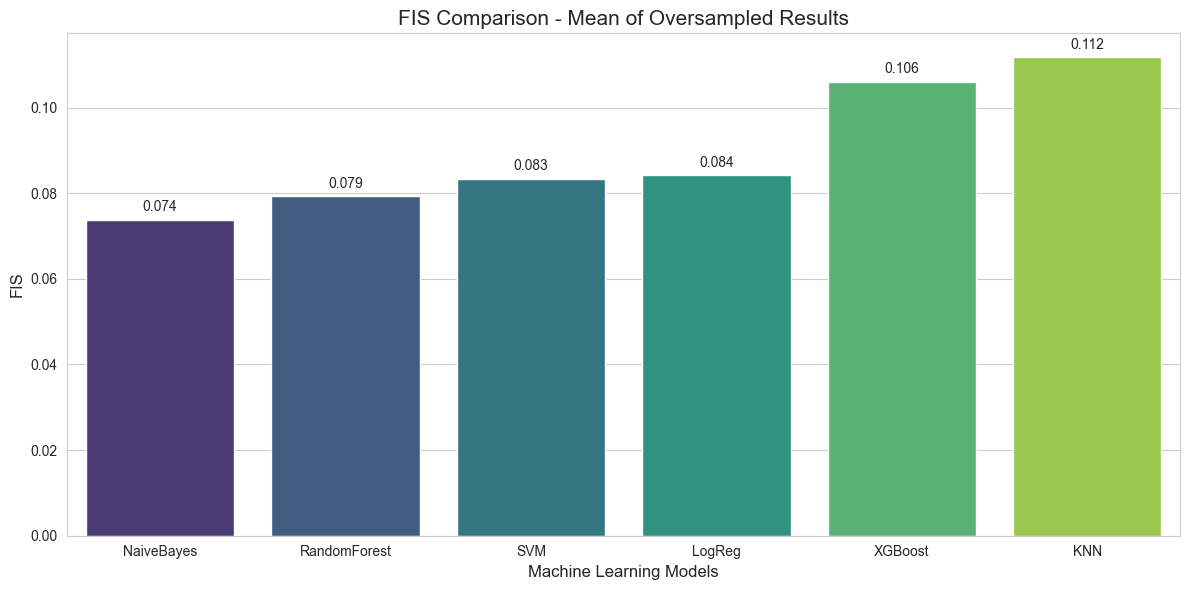

FIS Summary Table:
       Model    FIS
  NaiveBayes 0.0738
RandomForest 0.0793
         SVM 0.0834
      LogReg 0.0842
     XGBoost 0.1061
         KNN 0.1118


In [175]:
models_data_mean = [
    {"Model": "LogReg", "SPD": over_avg_spd_lr, "DI": over_avg_DI_lr, "EOD": over_avg_EOD_lr, "AAOD": over_avg_AAOD_lr},
    {"Model": "RandomForest", "SPD": over_avg_spd_rf, "DI": over_avg_DI_rf, "EOD": over_avg_EOD_rf, "AAOD": over_avg_AAOD_rf},
    {"Model": "XGBoost", "SPD": over_avg_spd_xgb, "DI": over_avg_DI_xgb, "EOD": over_avg_EOD_xgb, "AAOD": over_avg_AAOD_xgb},
    {"Model": "SVM", "SPD": over_avg_spd_svm, "DI": over_avg_DI_svm, "EOD": over_avg_EOD_svm, "AAOD": over_avg_AAOD_svm},
    {"Model": "KNN", "SPD": over_avg_spd_knn, "DI": over_avg_DI_knn, "EOD": over_avg_EOD_knn, "AAOD": over_avg_AAOD_knn},
    {"Model": "NaiveBayes", "SPD": over_avg_spd_nb, "DI": over_avg_DI_nb, "EOD": over_avg_EOD_nb, "AAOD": over_avg_AAOD_nb}
]

title = 'Mean of Oversampled Results'
visualize_fis(models_data_mean, title)

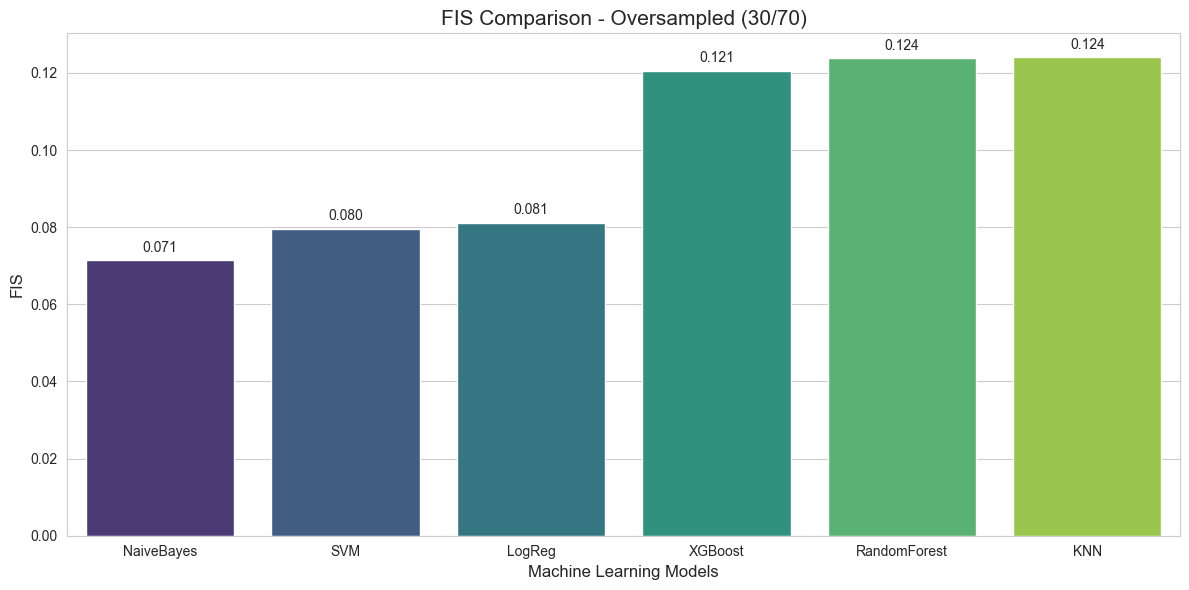

FIS Summary Table:
       Model    FIS
  NaiveBayes 0.0714
         SVM 0.0796
      LogReg 0.0812
     XGBoost 0.1206
RandomForest 0.1238
         KNN 0.1240


In [176]:
models_data_30 = [
    {"Model": "LogReg", "SPD": SPD_orig_lr2, "DI": DI_orig_lr2, "EOD": EOD_orig_lr2, "AAOD": AAOD_orig_lr2},
    {"Model": "RandomForest", "SPD": SPD_orig_rf2, "DI": DI_orig_rf2, "EOD": EOD_orig_rf2, "AAOD": AAOD_orig_rf2},
    {"Model": "XGBoost", "SPD": SPD_orig_xgb2, "DI": DI_orig_xgb2, "EOD": EOD_orig_xgb2, "AAOD": AAOD_orig_xgb2},
    {"Model": "SVM", "SPD": SPD_orig_svm2, "DI": DI_orig_svm2, "EOD": EOD_orig_svm2, "AAOD": AAOD_orig_svm2},
    {"Model": "KNN", "SPD": SPD_orig_knn2, "DI": DI_orig_knn2, "EOD": EOD_orig_knn2, "AAOD": AAOD_orig_knn2},
    {"Model": "NaiveBayes", "SPD": SPD_orig_nb2, "DI": DI_orig_nb2, "EOD": EOD_orig_nb2, "AAOD": AAOD_orig_nb2}
]

title = 'Oversampled (30/70)'
visualize_fis(models_data_30, title)

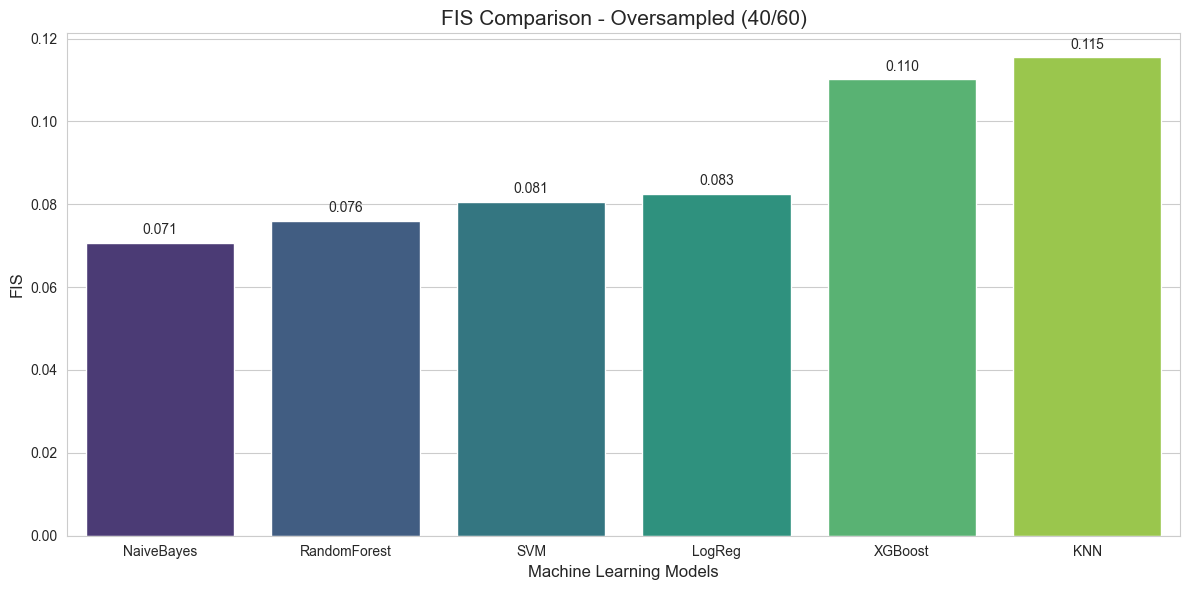

FIS Summary Table:
       Model    FIS
  NaiveBayes 0.0707
RandomForest 0.0760
         SVM 0.0807
      LogReg 0.0826
     XGBoost 0.1102
         KNN 0.1155


In [177]:
models_data_40 = [
    {"Model": "LogReg", "SPD": SPD_orig_lr3, "DI": DI_orig_lr3, "EOD": EOD_orig_lr3, "AAOD": AAOD_orig_lr3},
    {"Model": "RandomForest", "SPD": SPD_orig_rf3, "DI": DI_orig_rf3, "EOD": EOD_orig_rf3, "AAOD": AAOD_orig_rf3},
    {"Model": "XGBoost", "SPD": SPD_orig_xgb3, "DI": DI_orig_xgb3, "EOD": EOD_orig_xgb3, "AAOD": AAOD_orig_xgb3},
    {"Model": "SVM", "SPD": SPD_orig_svm3, "DI": DI_orig_svm3, "EOD": EOD_orig_svm3, "AAOD": AAOD_orig_svm3},
    {"Model": "KNN", "SPD": SPD_orig_knn3, "DI": DI_orig_knn3, "EOD": EOD_orig_knn3, "AAOD": AAOD_orig_knn3},
    {"Model": "NaiveBayes", "SPD": SPD_orig_nb3, "DI": DI_orig_nb3, "EOD": EOD_orig_nb3, "AAOD": AAOD_orig_nb3}
]

title = 'Oversampled (40/60)'
visualize_fis(models_data_40, title)

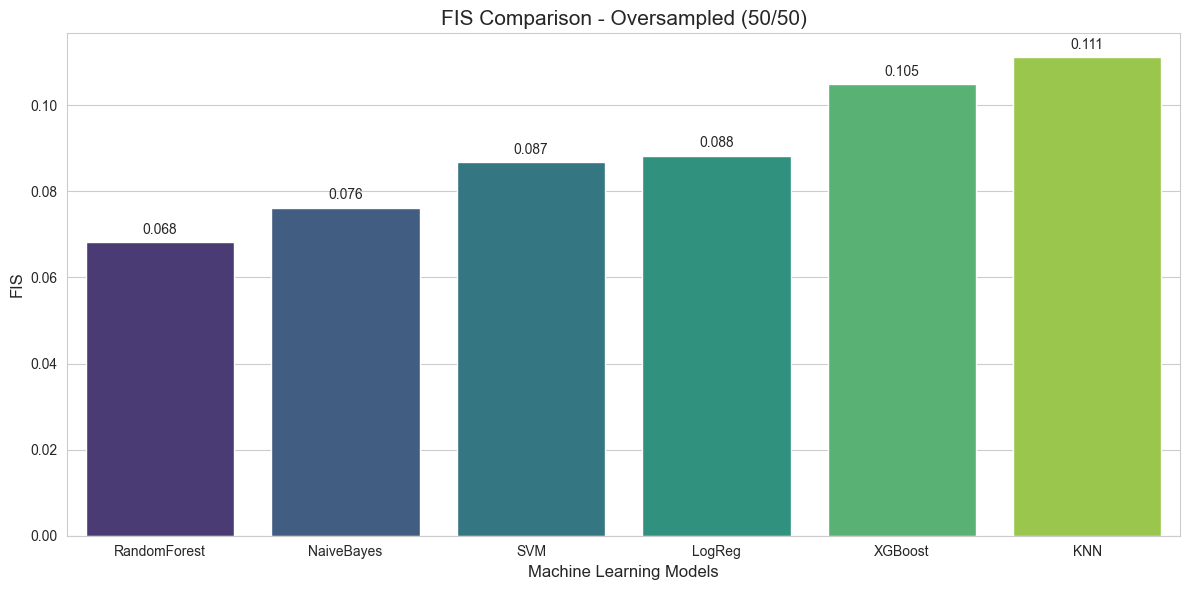

FIS Summary Table:
       Model    FIS
RandomForest 0.0682
  NaiveBayes 0.0762
         SVM 0.0868
      LogReg 0.0883
     XGBoost 0.1048
         KNN 0.1112


In [178]:
models_data_50 = [
    {"Model": "LogReg", "SPD": SPD_orig_lr4, "DI": DI_orig_lr4, "EOD": EOD_orig_lr4, "AAOD": AAOD_orig_lr4},
    {"Model": "RandomForest", "SPD": SPD_orig_rf4, "DI": DI_orig_rf4, "EOD": EOD_orig_rf4, "AAOD": AAOD_orig_rf4},
    {"Model": "XGBoost", "SPD": SPD_orig_xgb4, "DI": DI_orig_xgb4, "EOD": EOD_orig_xgb4, "AAOD": AAOD_orig_xgb4},
    {"Model": "SVM", "SPD": SPD_orig_svm4, "DI": DI_orig_svm4, "EOD": EOD_orig_svm4, "AAOD": AAOD_orig_svm4},
    {"Model": "KNN", "SPD": SPD_orig_knn4, "DI": DI_orig_knn4, "EOD": EOD_orig_knn4, "AAOD": AAOD_orig_knn4},
    {"Model": "NaiveBayes", "SPD": SPD_orig_nb4, "DI": DI_orig_nb4, "EOD": EOD_orig_nb4, "AAOD": AAOD_orig_nb4}
]

title = 'Oversampled (50/50)'
visualize_fis(models_data_50, title)

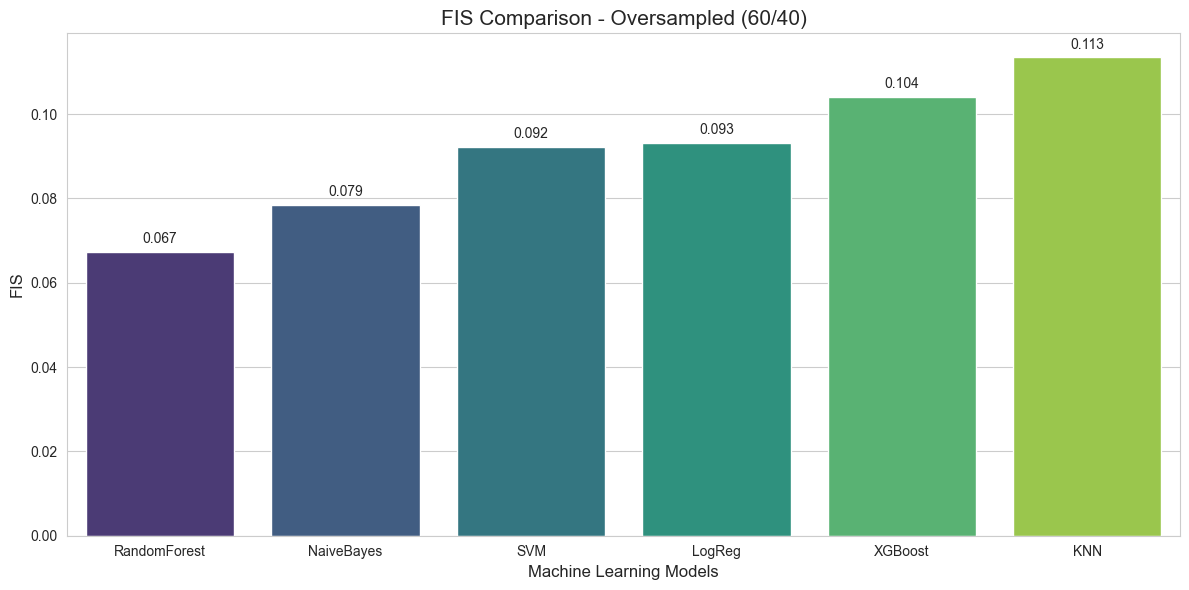

FIS Summary Table:
       Model    FIS
RandomForest 0.0673
  NaiveBayes 0.0786
         SVM 0.0923
      LogReg 0.0932
     XGBoost 0.1041
         KNN 0.1135


In [179]:
models_data_60 = [
    {"Model": "LogReg", "SPD": SPD_orig_lr5, "DI": DI_orig_lr5, "EOD": EOD_orig_lr5, "AAOD": AAOD_orig_lr5},
    {"Model": "RandomForest", "SPD": SPD_orig_rf5, "DI": DI_orig_rf5, "EOD": EOD_orig_rf5, "AAOD": AAOD_orig_rf5},
    {"Model": "XGBoost", "SPD": SPD_orig_xgb5, "DI": DI_orig_xgb5, "EOD": EOD_orig_xgb5, "AAOD": AAOD_orig_xgb5},
    {"Model": "SVM", "SPD": SPD_orig_svm5, "DI": DI_orig_svm5, "EOD": EOD_orig_svm5, "AAOD": AAOD_orig_svm5},
    {"Model": "KNN", "SPD": SPD_orig_knn5, "DI": DI_orig_knn5, "EOD": EOD_orig_knn5, "AAOD": AAOD_orig_knn5},
    {"Model": "NaiveBayes", "SPD": SPD_orig_nb5, "DI": DI_orig_nb5, "EOD": EOD_orig_nb5, "AAOD": AAOD_orig_nb5}
]

title = 'Oversampled (60/40)'
visualize_fis(models_data_60, title)

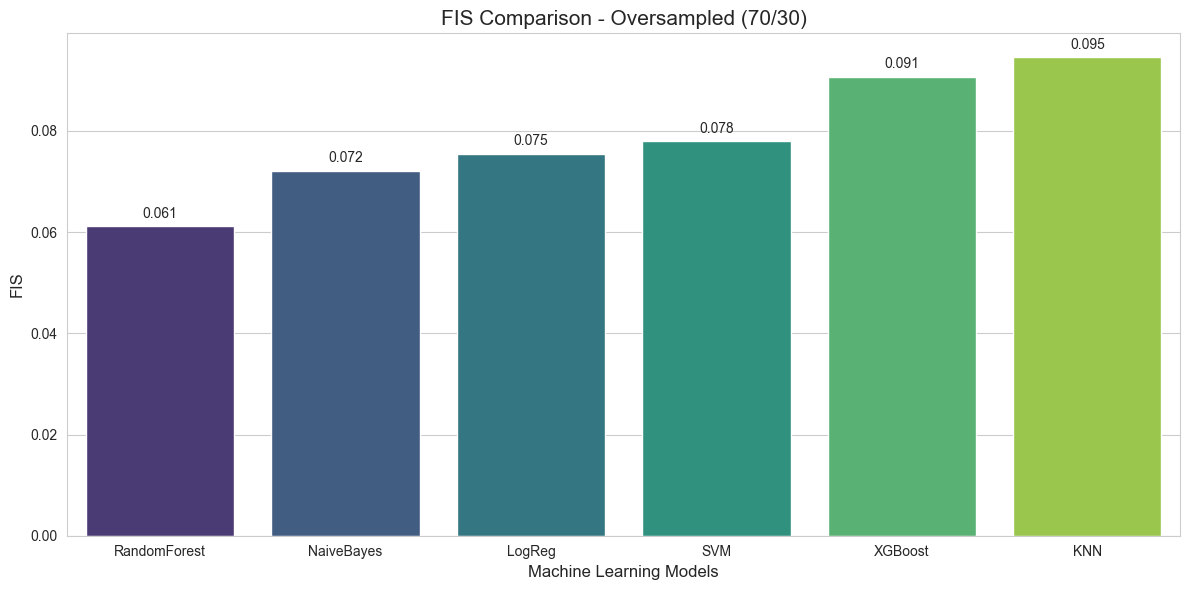

FIS Summary Table:
       Model    FIS
RandomForest 0.0611
  NaiveBayes 0.0721
      LogReg 0.0755
         SVM 0.0779
     XGBoost 0.0907
         KNN 0.0946


In [180]:
models_data_70 = [
    {"Model": "LogReg", "SPD": SPD_orig_lr6, "DI": DI_orig_lr6, "EOD": EOD_orig_lr6, "AAOD": AAOD_orig_lr6},
    {"Model": "RandomForest", "SPD": SPD_orig_rf6, "DI": DI_orig_rf6, "EOD": EOD_orig_rf6, "AAOD": AAOD_orig_rf6},
    {"Model": "XGBoost", "SPD": SPD_orig_xgb6, "DI": DI_orig_xgb6, "EOD": EOD_orig_xgb6, "AAOD": AAOD_orig_xgb6},
    {"Model": "SVM", "SPD": SPD_orig_svm6, "DI": DI_orig_svm6, "EOD": EOD_orig_svm6, "AAOD": AAOD_orig_svm6},
    {"Model": "KNN", "SPD": SPD_orig_knn6, "DI": DI_orig_knn6, "EOD": EOD_orig_knn6, "AAOD": AAOD_orig_knn6},
    {"Model": "NaiveBayes", "SPD": SPD_orig_nb6, "DI": DI_orig_nb6, "EOD": EOD_orig_nb6, "AAOD": AAOD_orig_nb6}
]

title = 'Oversampled (70/30)'
visualize_fis(models_data_70, title)

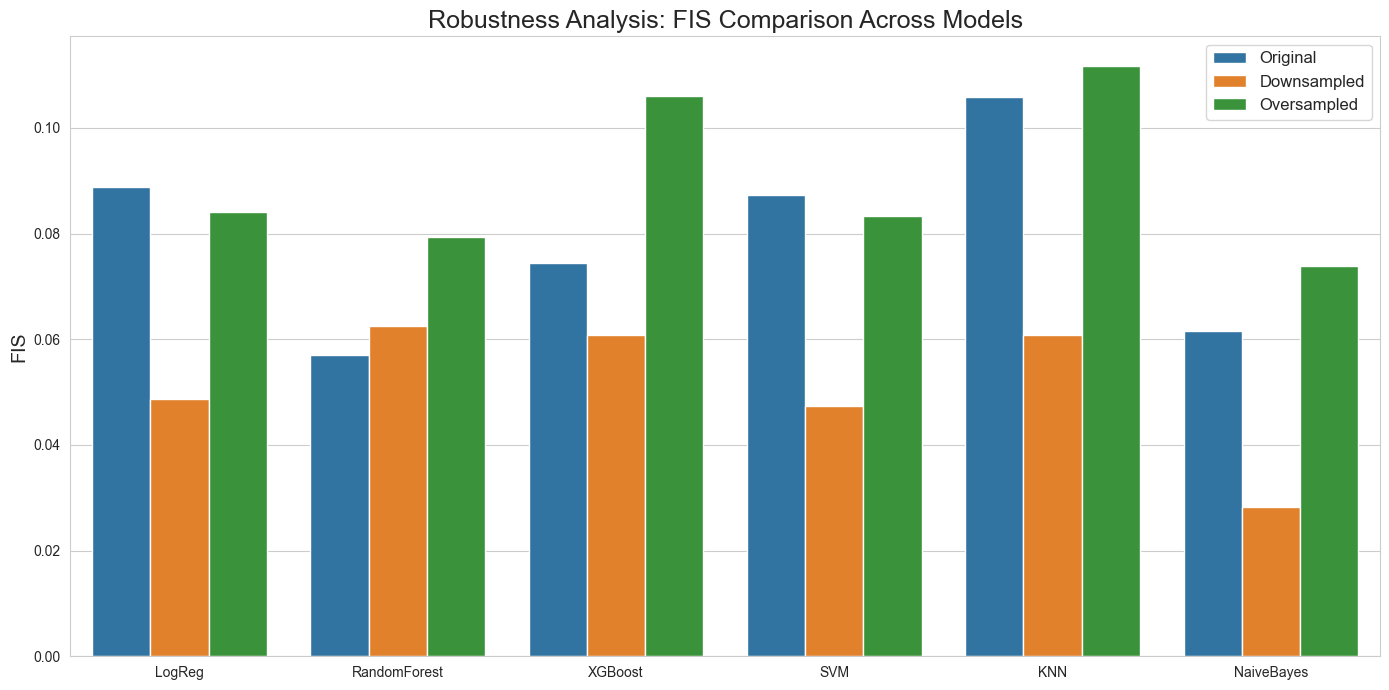

In [181]:
data = [
    # Logistic Regression
    {"Model": "LogReg", "Type": "Original", "FIS": calculate_fis(SPD_orig_lr, DI_orig_lr, EOD_orig_lr, AAOD_orig_lr)},
    {"Model": "LogReg", "Type": "Downsampled", "FIS": calculate_fis(down_avg_spd_lr, down_avg_DI_lr, down_avg_EOD_lr, down_avg_AAOD_lr)},
    {"Model": "LogReg", "Type": "Oversampled", "FIS": calculate_fis(over_avg_spd_lr, over_avg_DI_lr, over_avg_EOD_lr, over_avg_AAOD_lr)},
    
    # Random Forest
    {"Model": "RandomForest", "Type": "Original", "FIS": calculate_fis(SPD_orig_rf, DI_orig_rf, EOD_orig_rf, AAOD_orig_rf)},
    {"Model": "RandomForest", "Type": "Downsampled", "FIS": calculate_fis(down_avg_spd_rf, down_avg_DI_rf, down_avg_EOD_rf, down_avg_AAOD_rf)},
    {"Model": "RandomForest", "Type": "Oversampled", "FIS": calculate_fis(over_avg_spd_rf, over_avg_DI_rf, over_avg_EOD_rf, over_avg_AAOD_rf)},
    
    # XGBoost
    {"Model": "XGBoost", "Type": "Original", "FIS": calculate_fis(SPD_orig_xgb, DI_orig_xgb, EOD_orig_xgb, AAOD_orig_xgb)},
    {"Model": "XGBoost", "Type": "Downsampled", "FIS": calculate_fis(down_avg_spd_xgb, down_avg_DI_xgb, down_avg_EOD_xgb, down_avg_AAOD_xgb)},
    {"Model": "XGBoost", "Type": "Oversampled", "FIS": calculate_fis(over_avg_spd_xgb, over_avg_DI_xgb, over_avg_EOD_xgb, over_avg_AAOD_xgb)},
    
    # SVM
    {"Model": "SVM", "Type": "Original", "FIS": calculate_fis(SPD_orig_svm, DI_orig_svm, EOD_orig_svm, AAOD_orig_svm)},
    {"Model": "SVM", "Type": "Downsampled", "FIS": calculate_fis(down_avg_spd_svm, down_avg_DI_svm, down_avg_EOD_svm, down_avg_AAOD_svm)},
    {"Model": "SVM", "Type": "Oversampled", "FIS": calculate_fis(over_avg_spd_svm, over_avg_DI_svm, over_avg_EOD_svm, over_avg_AAOD_svm)},
    
    # KNN
    {"Model": "KNN", "Type": "Original", "FIS": calculate_fis(SPD_orig_knn, DI_orig_knn, EOD_orig_knn, AAOD_orig_knn)},
    {"Model": "KNN", "Type": "Downsampled", "FIS": calculate_fis(down_avg_spd_knn, down_avg_DI_knn, down_avg_EOD_knn, down_avg_AAOD_knn)},
    {"Model": "KNN", "Type": "Oversampled", "FIS": calculate_fis(over_avg_spd_knn, over_avg_DI_knn, over_avg_EOD_knn, over_avg_AAOD_knn)},
    
    # Naive Bayes
    {"Model": "NaiveBayes", "Type": "Original", "FIS": calculate_fis(SPD_orig_nb, DI_orig_nb, EOD_orig_nb, AAOD_orig_nb)},
    {"Model": "NaiveBayes", "Type": "Downsampled", "FIS": calculate_fis(down_avg_spd_nb, down_avg_DI_nb, down_avg_EOD_nb, down_avg_AAOD_nb)},
    {"Model": "NaiveBayes", "Type": "Oversampled", "FIS": calculate_fis(over_avg_spd_nb, over_avg_DI_nb, over_avg_EOD_nb, over_avg_AAOD_nb)}
]

df_plot = pd.DataFrame(data)
plt.figure(figsize=(14, 7))

ax = sns.barplot(x='Model', y='FIS', hue='Type', data=df_plot, palette='tab10')

plt.legend(loc='upper right', fontsize=12)
plt.title('Robustness Analysis: FIS Comparison Across Models', fontsize=18)
plt.xlabel('')
plt.ylabel('FIS', fontsize=14)
plt.tight_layout()
plt.show()